In [ ]:
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import ROOT

from coincidence_scripts_python.coincidence_lib import (
    SAMPLE_PERIOD_NS,
    WaveformAnalyzer,
)

/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [5]:

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

INPUT_LIST = Path("input_list.txt")
CONFIG_FILE = Path("waveform_intervals.ini")
WINDOW_TICKS = 10
N_EXAMPLES = 50

CSV_FILE = "waveforms_run_039510_coinc_2030-2031-2040-2041_vs_2050-2051-2060-2061_save_2070-2071-2080-2081_window_5_ticks_min_amplitude_1000_adc.csv"

LABEL = CSV_FILE.replace(".csv", "").replace("waveforms_", "")
# ------------------------------------------------------------------
# Read selected waveform information
# ------------------------------------------------------------------

selected = pd.read_csv(CSV_FILE)

save_channel_column = (
    "channel_save" if "channel_save" in selected.columns else "channel"
)
required_columns = {
    save_channel_column,
    "event",
    "waveform_index_save",
    "dt_ns_coinc",
    "dt_ns_save",
    "channel_coincident_left",
    "waveform_index_coincident_left",
    "channel_coincident_right",
    "waveform_index_coincident_right",
}
missing_columns = required_columns - set(selected.columns)

if missing_columns:
    raise ValueError(f"Missing CSV columns: {sorted(missing_columns)}")

# Load only a small, reproducible sample of CSV coincidence groups.
example_rows = selected.sample(
    n=min(N_EXAMPLES, len(selected)),
    random_state=12345,
).copy()

def waveform_key(row, channel_column, waveform_column):
    return (
        int(row.event),
        int(getattr(row, channel_column)),
        int(getattr(row, waveform_column)),
    )

selected_keys = set()
for row in example_rows.itertuples():
    selected_keys.add(waveform_key(row, save_channel_column, "waveform_index_save"))
    selected_keys.add(waveform_key(
        row, "channel_coincident_left", "waveform_index_coincident_left"
    ))
    selected_keys.add(waveform_key(
        row, "channel_coincident_right", "waveform_index_coincident_right"
    ))

selected_channels = sorted({channel for _, channel, _ in selected_keys})

print(f"Selected CSV rows: {len(selected):,}")
print(f"Coincidence groups to inspect: {len(example_rows):,}")
print(f"Channels to load: {selected_channels}")

# ------------------------------------------------------------------
# Read ROOT filenames relative to input_list.txt
# ------------------------------------------------------------------

root_files = []

for line in INPUT_LIST.read_text().splitlines():
    line = line.strip()

    if line and not line.startswith("#"):
        root_files.append(
            str((INPUT_LIST.parent / line).resolve())
        )

if not root_files:
    raise RuntimeError(f"No ROOT files found in {INPUT_LIST}")

chain = ROOT.TChain("WaveformTree")

for filename in root_files:
    if chain.Add(filename) == 0:
        raise RuntimeError(f"Could not add ROOT file: {filename}")

print(f"ROOT files: {len(root_files)}")
print(f"Tree entries: {chain.GetEntries():,}")


Selected CSV rows: 37,930
Coincidence groups to inspect: 50
Channels to load: [2030, 2031, 2040, 2041, 2050, 2051, 2060, 2061, 2070, 2071, 2080, 2081]
ROOT files: 6
Tree entries: 8,292,065


Located ROOT entries: 150

Group 1, CSV row 5706, event 888
  left : channel=2031, waveform_index=377, timestamp=109892832034311792 ns, pulse_start=60 ticks, pulse_time=109892832034312752 ns
  right: channel=2060, waveform_index=336, timestamp=109892832034311792 ns, pulse_start=63 ticks, pulse_time=109892832034312800 ns
  saved: channel=2081, waveform_index=134, timestamp=109892832034311808 ns, pulse_start=60 ticks, pulse_time=109892832034312768 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=16, calculated=16


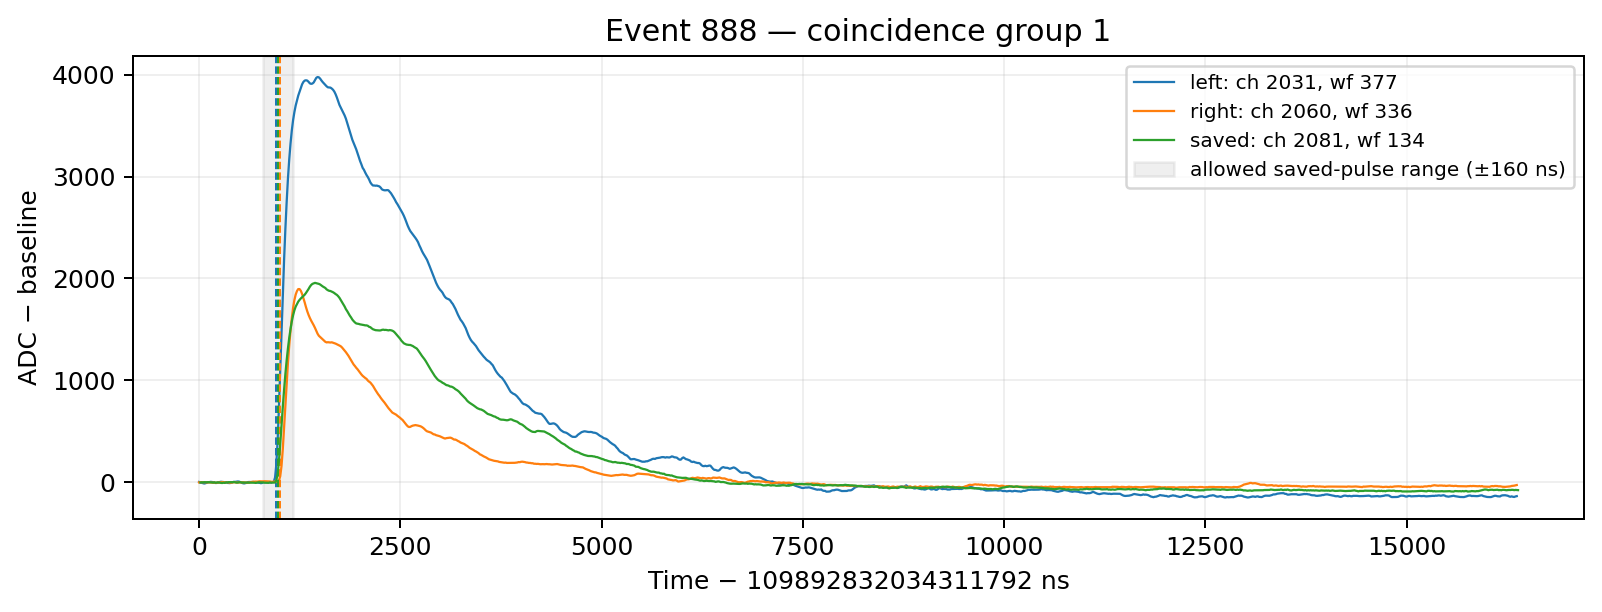


Group 2, CSV row 31017, event 4854
  left : channel=2030, waveform_index=18, timestamp=109892844493331456 ns, pulse_start=59 ticks, pulse_time=109892844493332400 ns
  right: channel=2050, waveform_index=165, timestamp=109892844493331472 ns, pulse_start=61 ticks, pulse_time=109892844493332448 ns
  saved: channel=2081, waveform_index=423, timestamp=109892844493331472 ns, pulse_start=58 ticks, pulse_time=109892844493332400 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=0, calculated=0


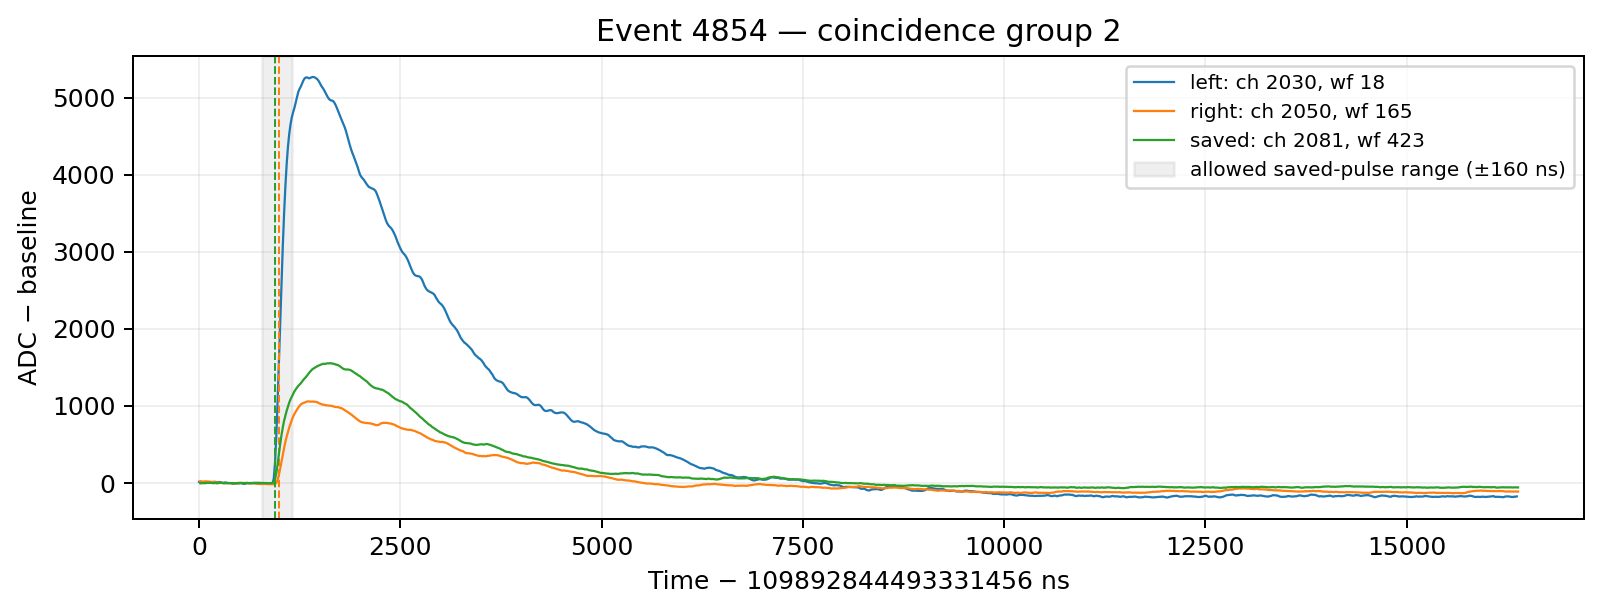


Group 3, CSV row 15612, event 2452
  left : channel=2041, waveform_index=487, timestamp=109892836947073024 ns, pulse_start=60 ticks, pulse_time=109892836947073984 ns
  right: channel=2060, waveform_index=447, timestamp=109892836947073024 ns, pulse_start=63 ticks, pulse_time=109892836947074032 ns
  saved: channel=2081, waveform_index=152, timestamp=109892836947073024 ns, pulse_start=60 ticks, pulse_time=109892836947073984 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=0, calculated=0


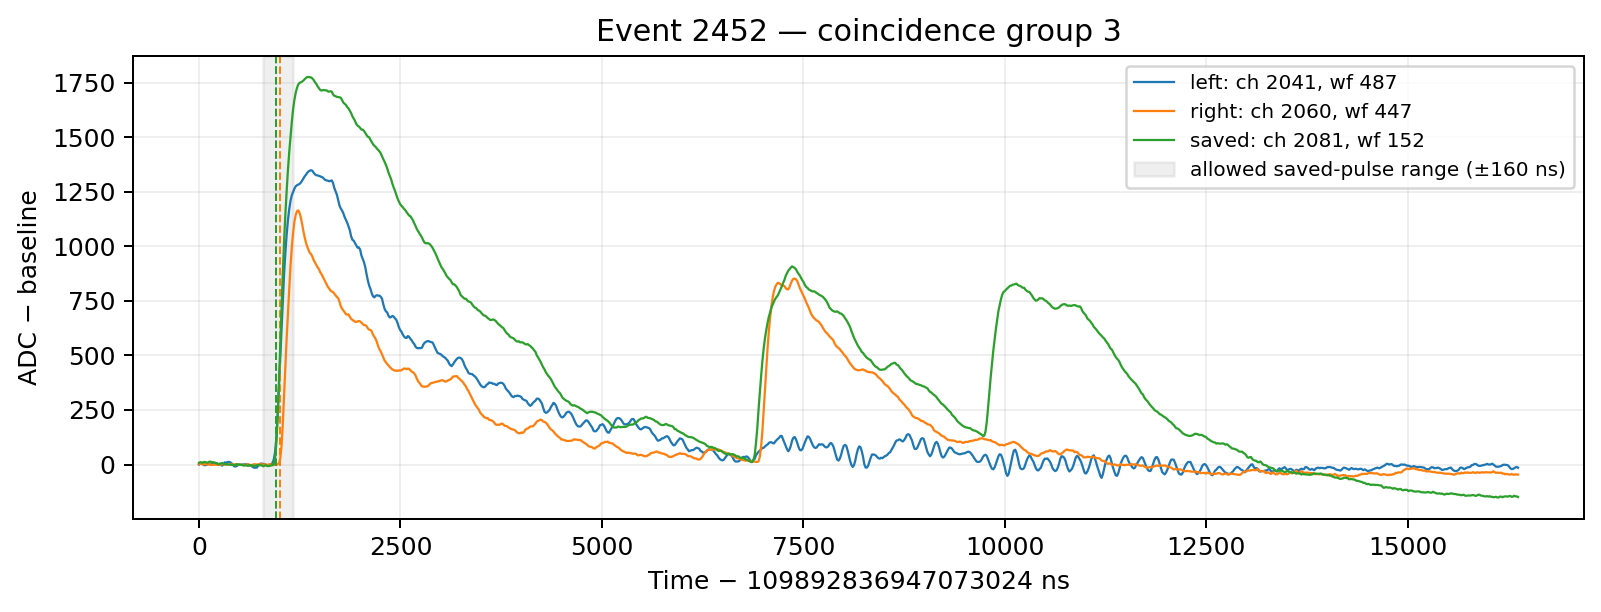


Group 4, CSV row 728, event 114
  left : channel=2040, waveform_index=100, timestamp=109892829602646960 ns, pulse_start=60 ticks, pulse_time=109892829602647920 ns
  right: channel=2050, waveform_index=328, timestamp=109892829602646960 ns, pulse_start=59 ticks, pulse_time=109892829602647904 ns
  saved: channel=2081, waveform_index=438, timestamp=109892829602646960 ns, pulse_start=57 ticks, pulse_time=109892829602647872 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=-32, calculated=-32


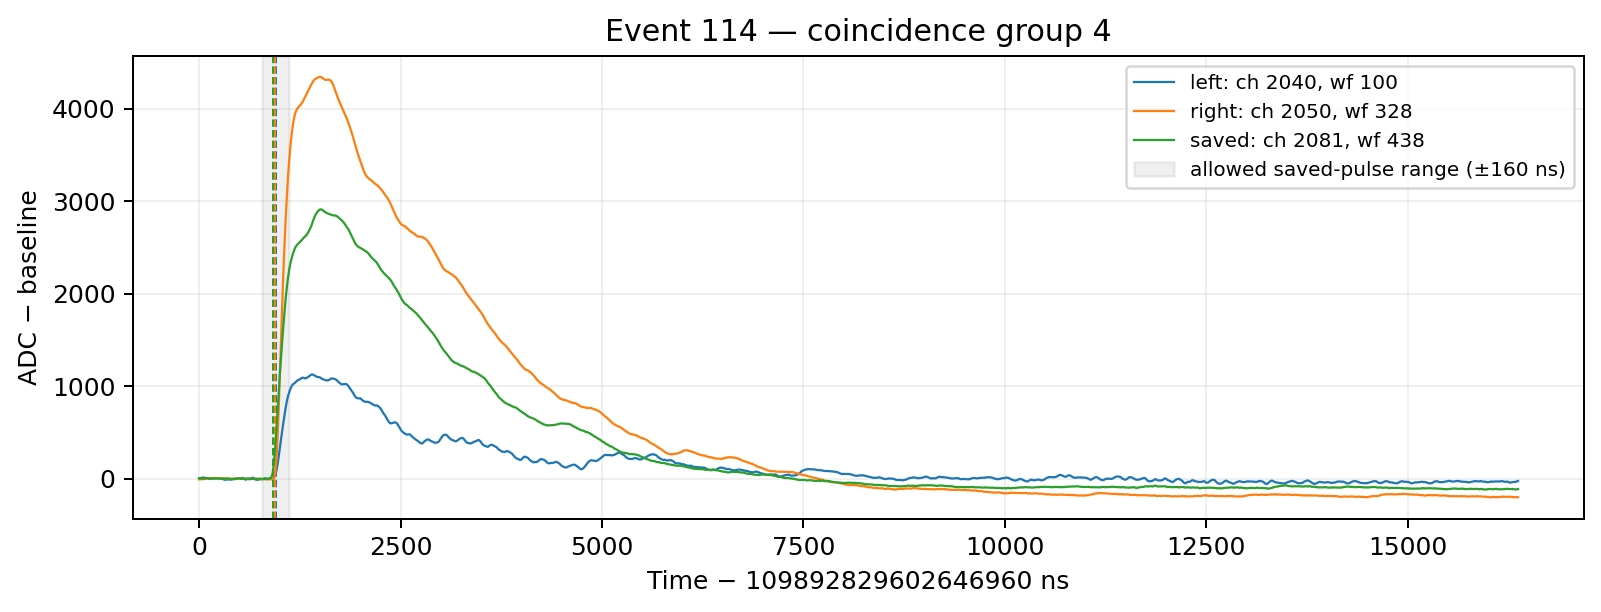


Group 5, CSV row 17433, event 2740
  left : channel=2030, waveform_index=449, timestamp=109892837852309936 ns, pulse_start=60 ticks, pulse_time=109892837852310896 ns
  right: channel=2050, waveform_index=332, timestamp=109892837852309936 ns, pulse_start=59 ticks, pulse_time=109892837852310880 ns
  saved: channel=2080, waveform_index=413, timestamp=109892837852309936 ns, pulse_start=58 ticks, pulse_time=109892837852310864 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=-16, calculated=-16


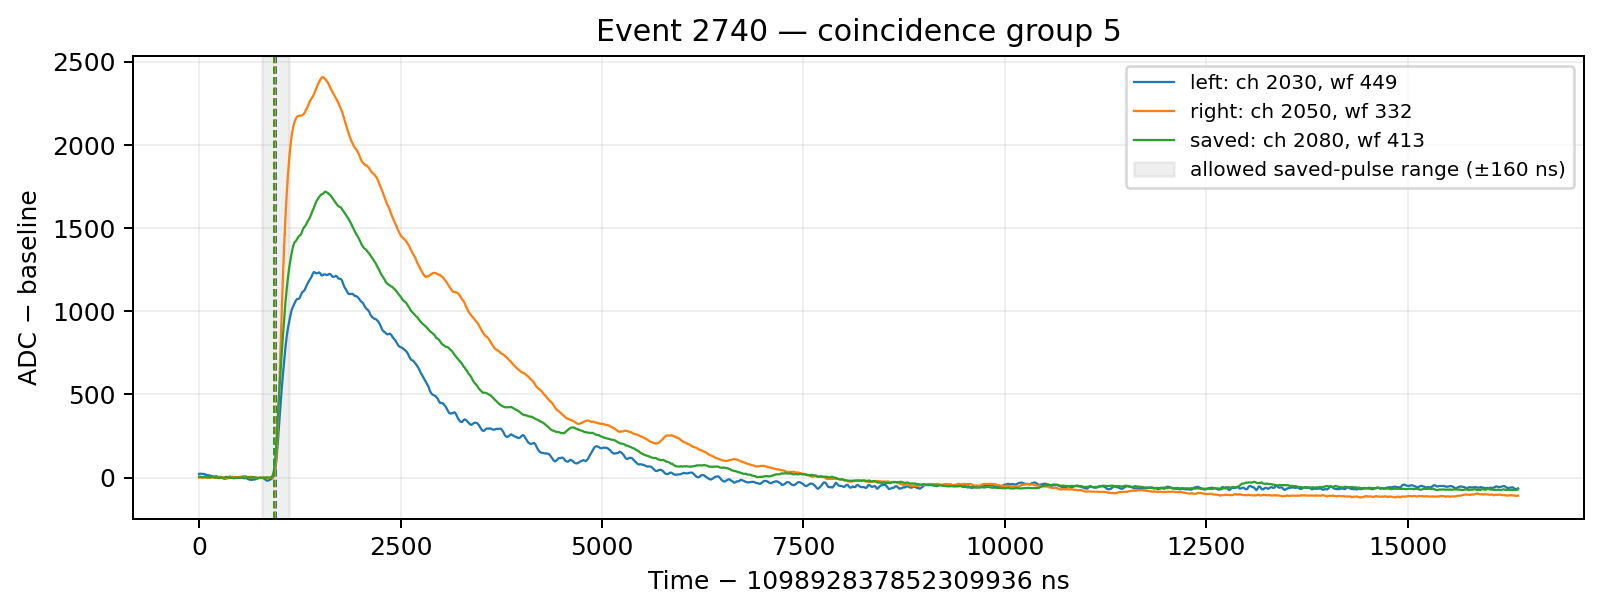


Group 6, CSV row 81, event 10
  left : channel=2030, waveform_index=538, timestamp=109892829275627312 ns, pulse_start=60 ticks, pulse_time=109892829275628272 ns
  right: channel=2050, waveform_index=312, timestamp=109892829275627312 ns, pulse_start=59 ticks, pulse_time=109892829275628256 ns
  saved: channel=2081, waveform_index=256, timestamp=109892829275627312 ns, pulse_start=58 ticks, pulse_time=109892829275628240 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=-16, calculated=-16


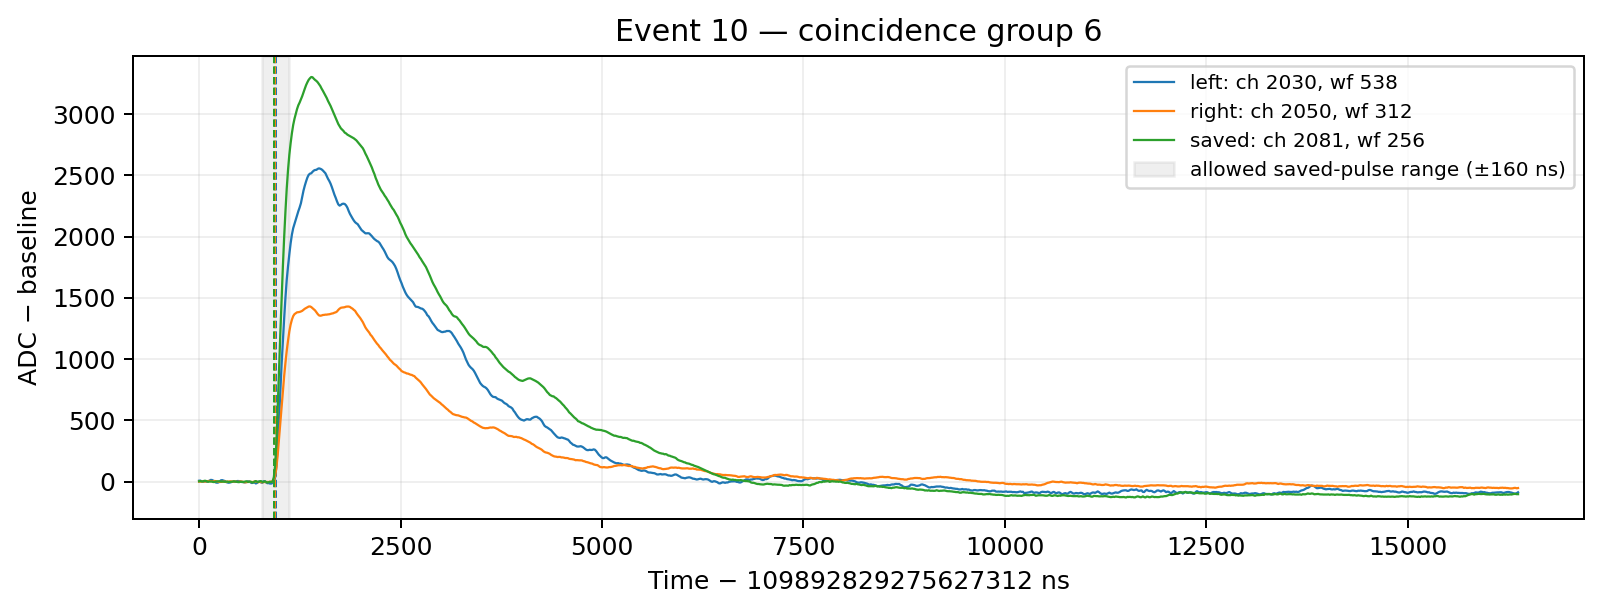


Group 7, CSV row 5449, event 845
  left : channel=2030, waveform_index=310, timestamp=109892831899437344 ns, pulse_start=60 ticks, pulse_time=109892831899438304 ns
  right: channel=2061, waveform_index=555, timestamp=109892831899437344 ns, pulse_start=62 ticks, pulse_time=109892831899438336 ns
  saved: channel=2080, waveform_index=400, timestamp=109892831899437360 ns, pulse_start=59 ticks, pulse_time=109892831899438304 ns
  dt_ns_coinc: CSV=32, calculated=32
  dt_ns_save:  CSV=0, calculated=0


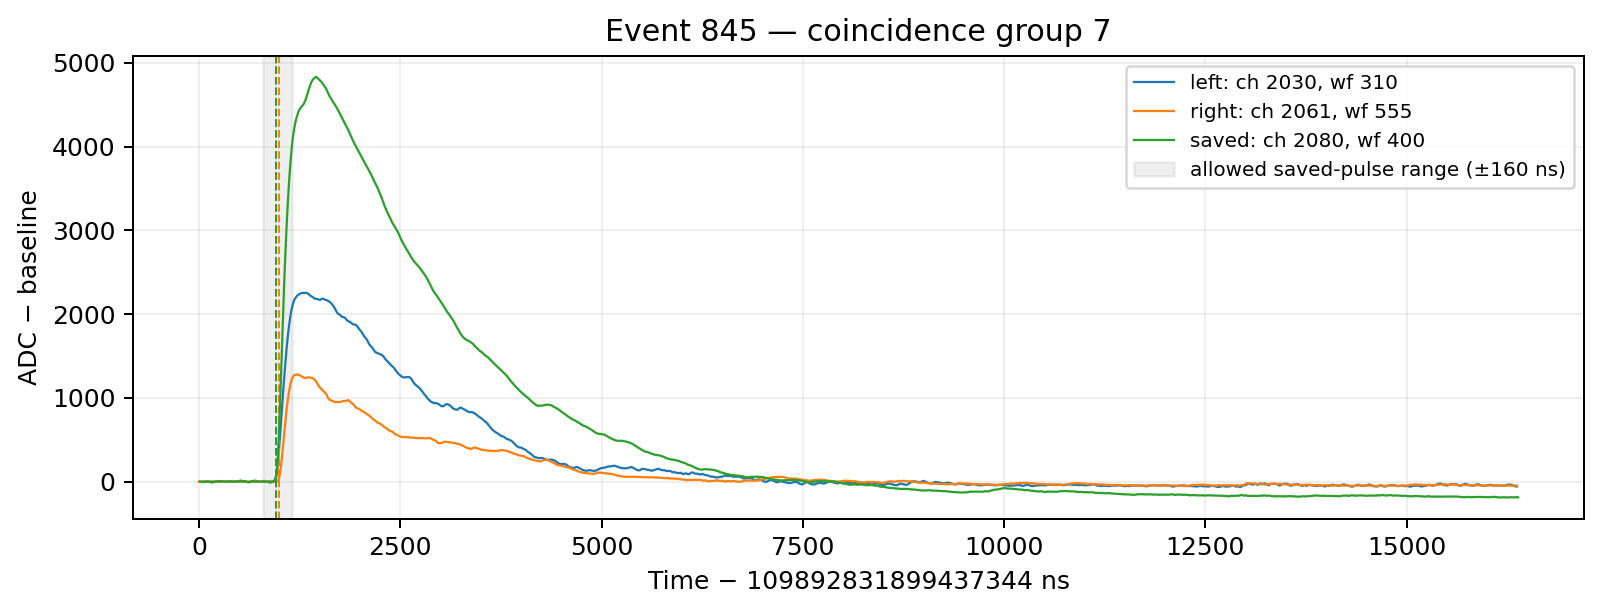


Group 8, CSV row 1329, event 212
  left : channel=2030, waveform_index=550, timestamp=109892829910366640 ns, pulse_start=61 ticks, pulse_time=109892829910367616 ns
  right: channel=2060, waveform_index=432, timestamp=109892829910366640 ns, pulse_start=63 ticks, pulse_time=109892829910367648 ns
  saved: channel=2081, waveform_index=184, timestamp=109892829910366656 ns, pulse_start=60 ticks, pulse_time=109892829910367616 ns
  dt_ns_coinc: CSV=32, calculated=32
  dt_ns_save:  CSV=0, calculated=0


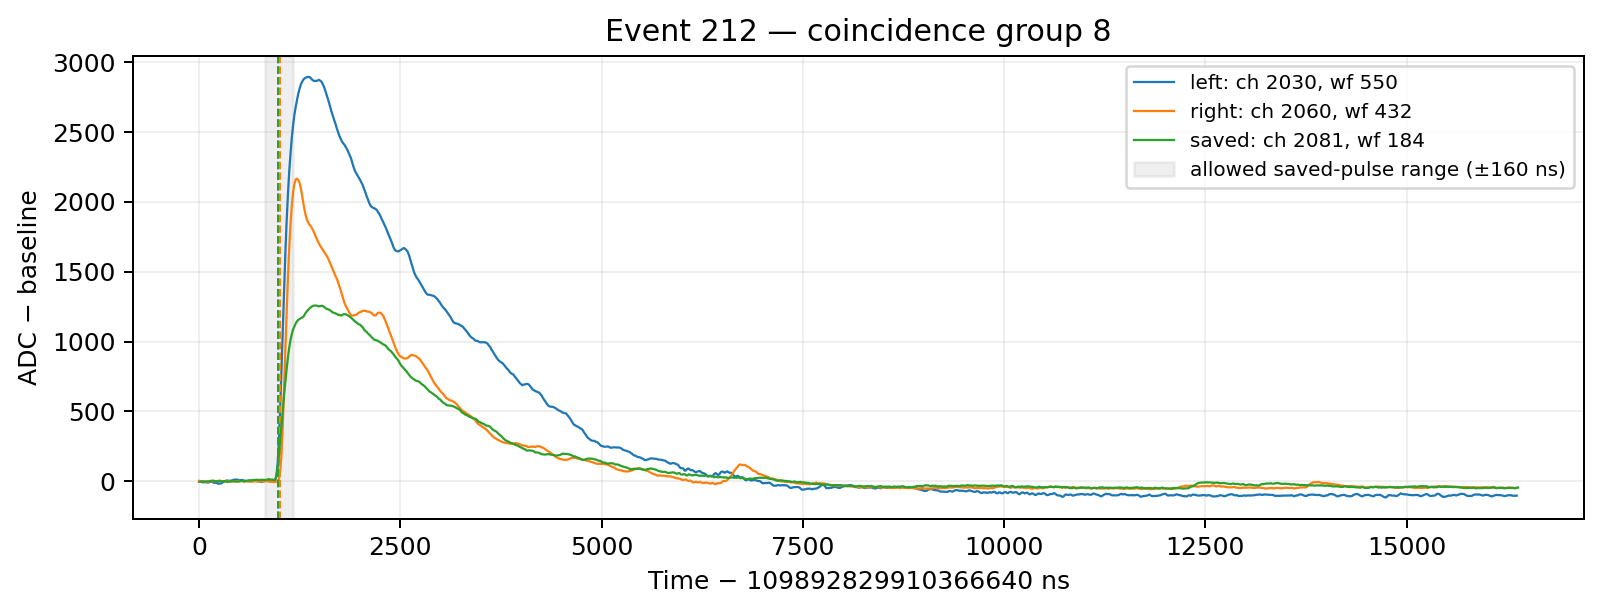


Group 9, CSV row 694, event 110
  left : channel=2040, waveform_index=314, timestamp=109892829590263632 ns, pulse_start=61 ticks, pulse_time=109892829590264608 ns
  right: channel=2060, waveform_index=135, timestamp=109892829590263632 ns, pulse_start=66 ticks, pulse_time=109892829590264688 ns
  saved: channel=2081, waveform_index=242, timestamp=109892829590263632 ns, pulse_start=60 ticks, pulse_time=109892829590264592 ns
  dt_ns_coinc: CSV=80, calculated=80
  dt_ns_save:  CSV=-16, calculated=-16


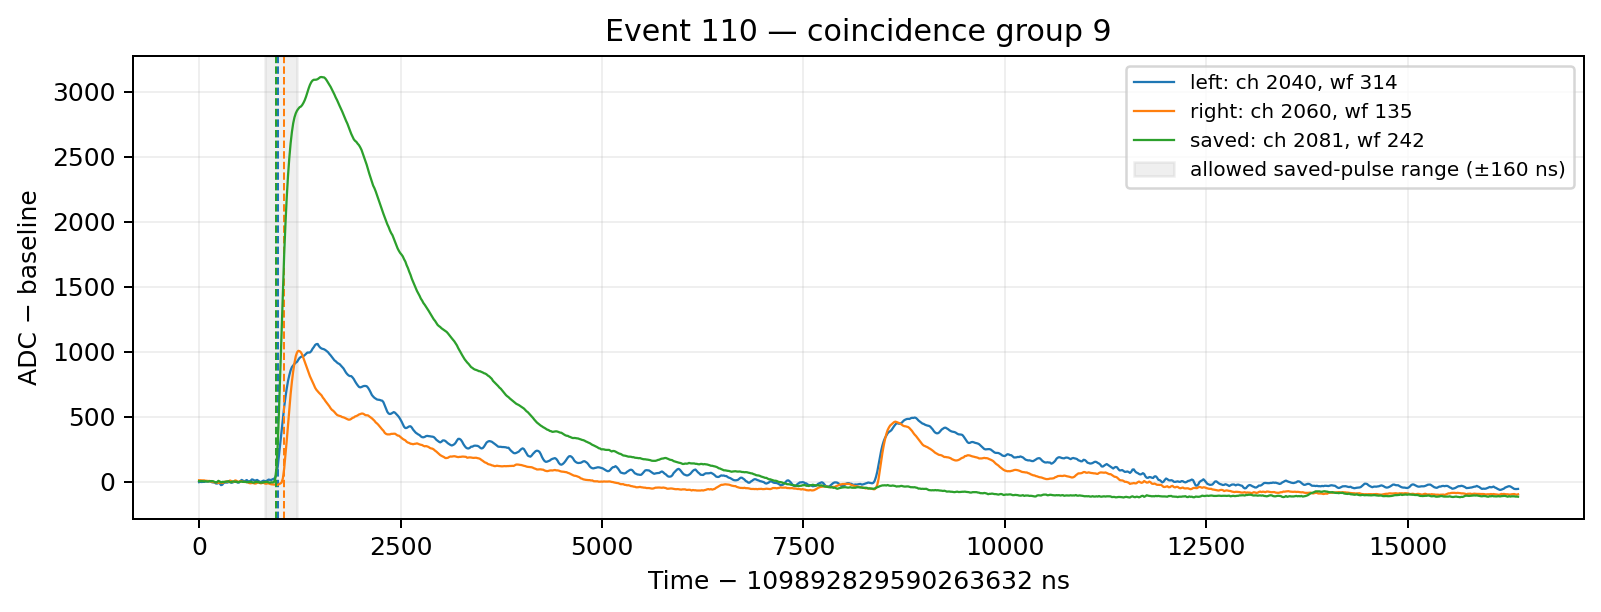


Group 10, CSV row 34728, event 5471
  left : channel=2030, waveform_index=587, timestamp=109892846431690976 ns, pulse_start=61 ticks, pulse_time=109892846431691952 ns
  right: channel=2060, waveform_index=494, timestamp=109892846431690896 ns, pulse_start=62 ticks, pulse_time=109892846431691888 ns
  saved: channel=2080, waveform_index=352, timestamp=109892846431690976 ns, pulse_start=62 ticks, pulse_time=109892846431691968 ns
  dt_ns_coinc: CSV=-64, calculated=-64
  dt_ns_save:  CSV=80, calculated=80


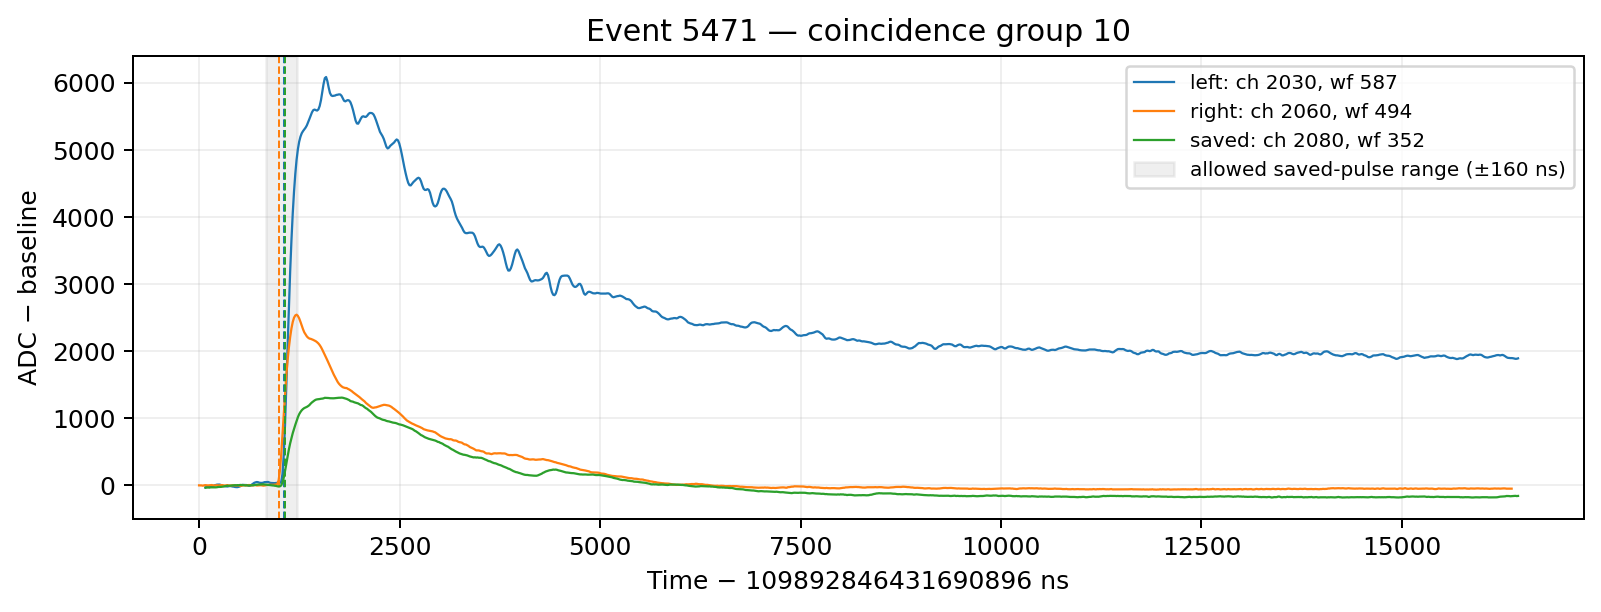


Group 11, CSV row 1812, event 293
  left : channel=2041, waveform_index=309, timestamp=109892830164986304 ns, pulse_start=60 ticks, pulse_time=109892830164987264 ns
  right: channel=2060, waveform_index=439, timestamp=109892830164986304 ns, pulse_start=61 ticks, pulse_time=109892830164987280 ns
  saved: channel=2071, waveform_index=584, timestamp=109892830164986288 ns, pulse_start=66 ticks, pulse_time=109892830164987344 ns
  dt_ns_coinc: CSV=16, calculated=16
  dt_ns_save:  CSV=80, calculated=80


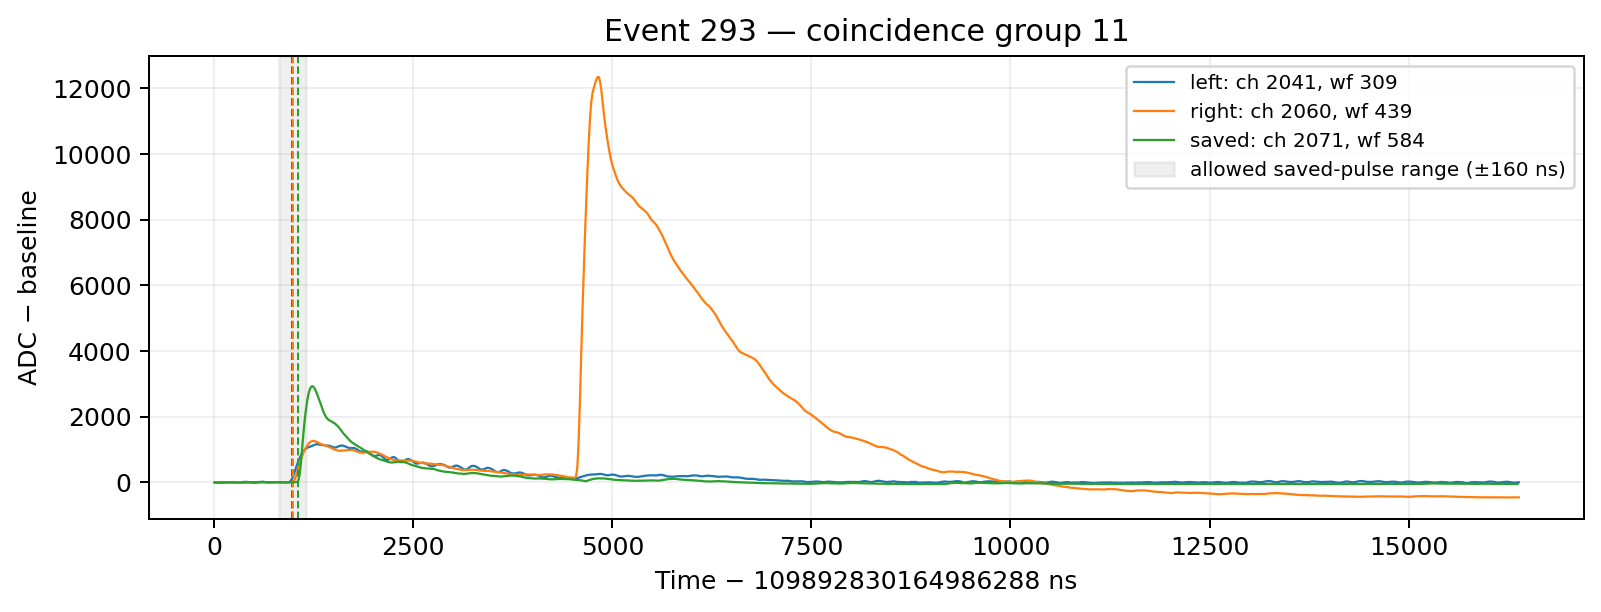


Group 12, CSV row 4105, event 642
  left : channel=2040, waveform_index=409, timestamp=109892831261468304 ns, pulse_start=65 ticks, pulse_time=109892831261469344 ns
  right: channel=2050, waveform_index=65, timestamp=109892831261468320 ns, pulse_start=59 ticks, pulse_time=109892831261469264 ns
  saved: channel=2081, waveform_index=488, timestamp=109892831261468320 ns, pulse_start=57 ticks, pulse_time=109892831261469232 ns
  dt_ns_coinc: CSV=-80, calculated=-80
  dt_ns_save:  CSV=-32, calculated=-32


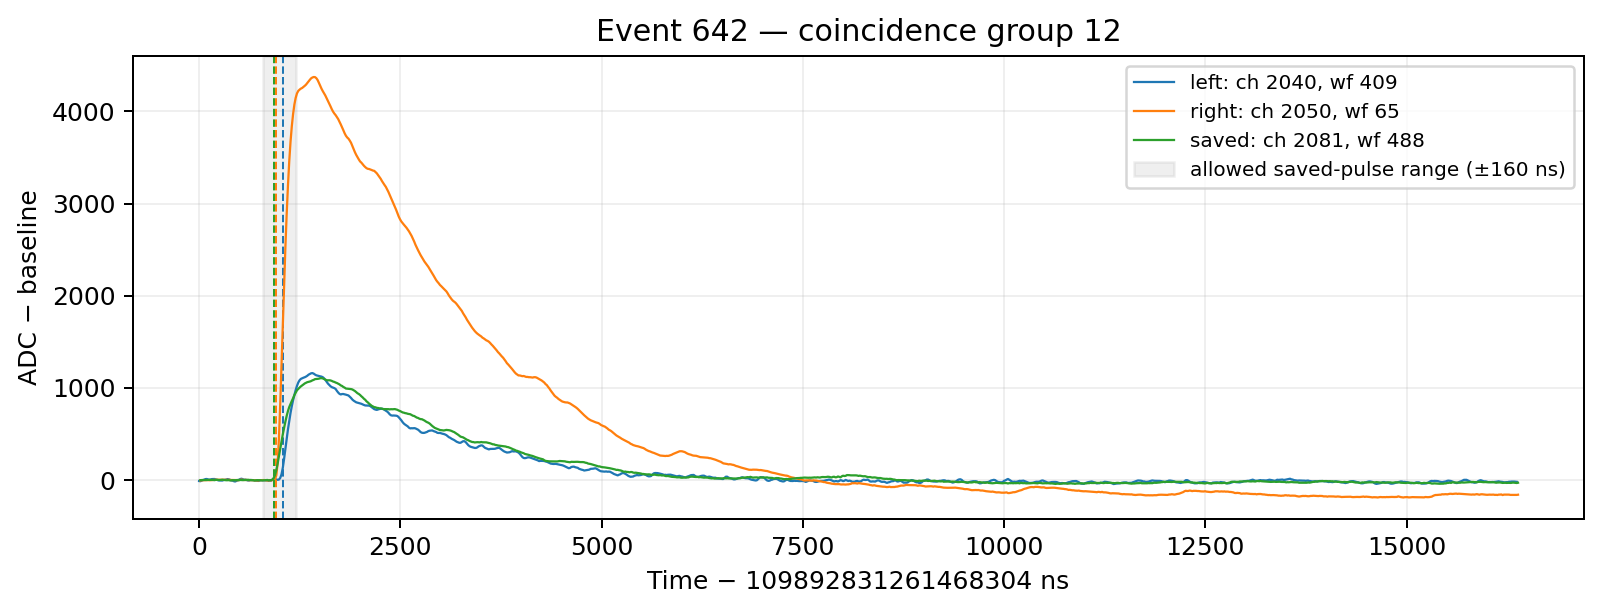


Group 13, CSV row 30502, event 4770
  left : channel=2040, waveform_index=124, timestamp=109892844229716432 ns, pulse_start=61 ticks, pulse_time=109892844229717408 ns
  right: channel=2061, waveform_index=283, timestamp=109892844229716384 ns, pulse_start=63 ticks, pulse_time=109892844229717392 ns
  saved: channel=2080, waveform_index=382, timestamp=109892844229716432 ns, pulse_start=63 ticks, pulse_time=109892844229717440 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=48, calculated=48


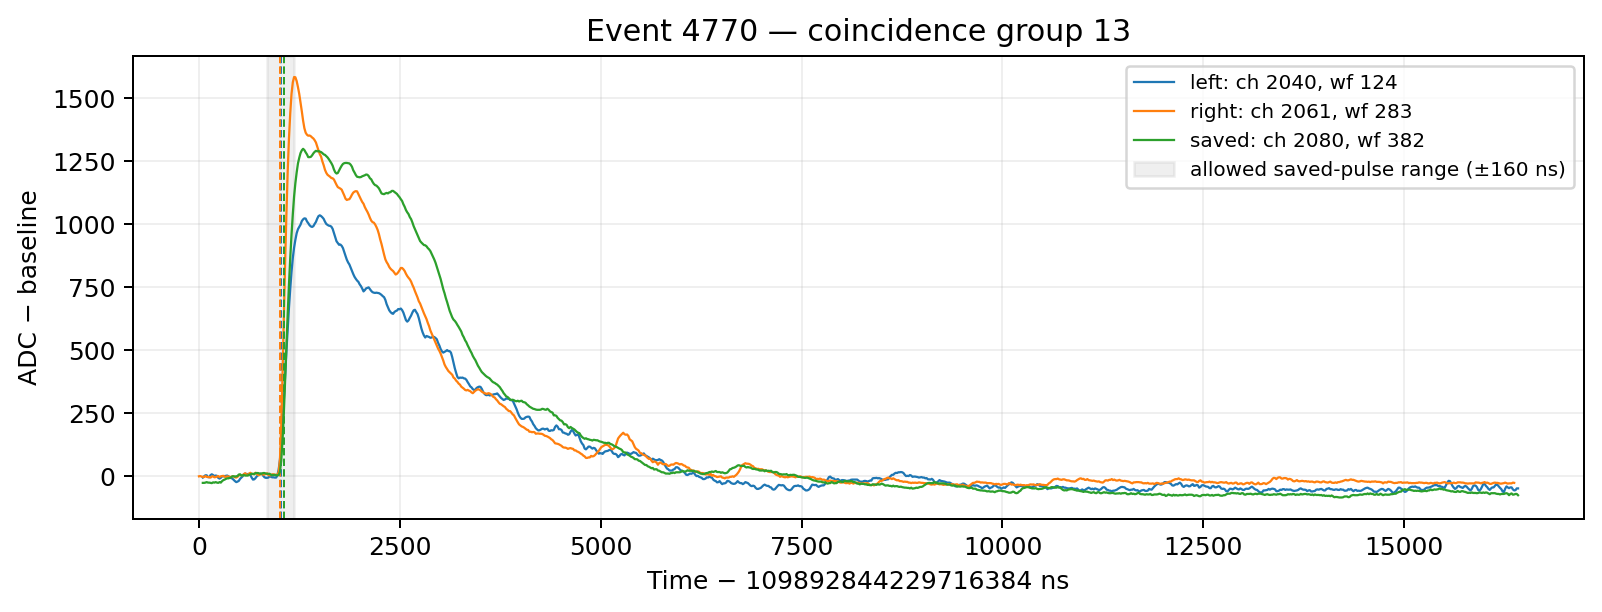


Group 14, CSV row 17951, event 2823
  left : channel=2030, waveform_index=402, timestamp=109892838112873056 ns, pulse_start=60 ticks, pulse_time=109892838112874016 ns
  right: channel=2060, waveform_index=218, timestamp=109892838112873056 ns, pulse_start=63 ticks, pulse_time=109892838112874064 ns
  saved: channel=2080, waveform_index=175, timestamp=109892838112873056 ns, pulse_start=60 ticks, pulse_time=109892838112874016 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=0, calculated=0


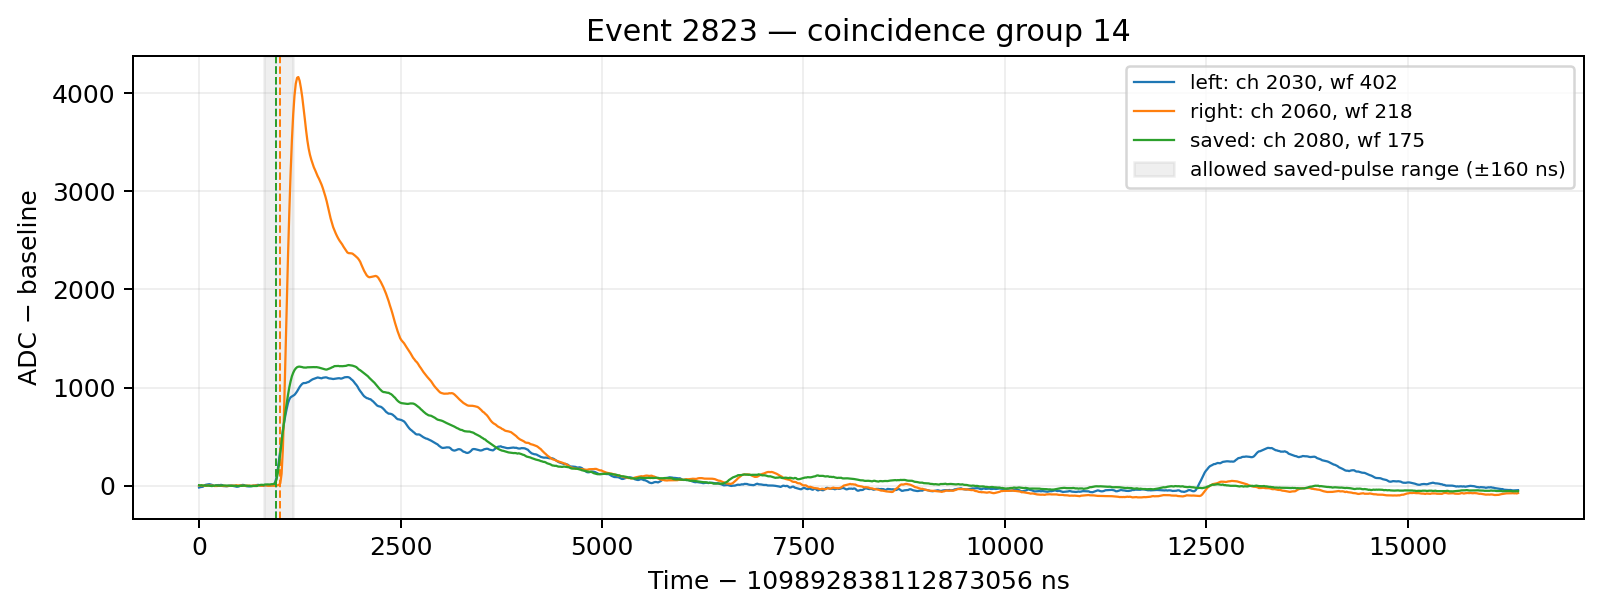


Group 15, CSV row 37037, event 5835
  left : channel=2031, waveform_index=236, timestamp=109892847575241248 ns, pulse_start=60 ticks, pulse_time=109892847575242208 ns
  right: channel=2060, waveform_index=282, timestamp=109892847575241248 ns, pulse_start=65 ticks, pulse_time=109892847575242288 ns
  saved: channel=2081, waveform_index=205, timestamp=109892847575241248 ns, pulse_start=59 ticks, pulse_time=109892847575242192 ns
  dt_ns_coinc: CSV=80, calculated=80
  dt_ns_save:  CSV=-16, calculated=-16


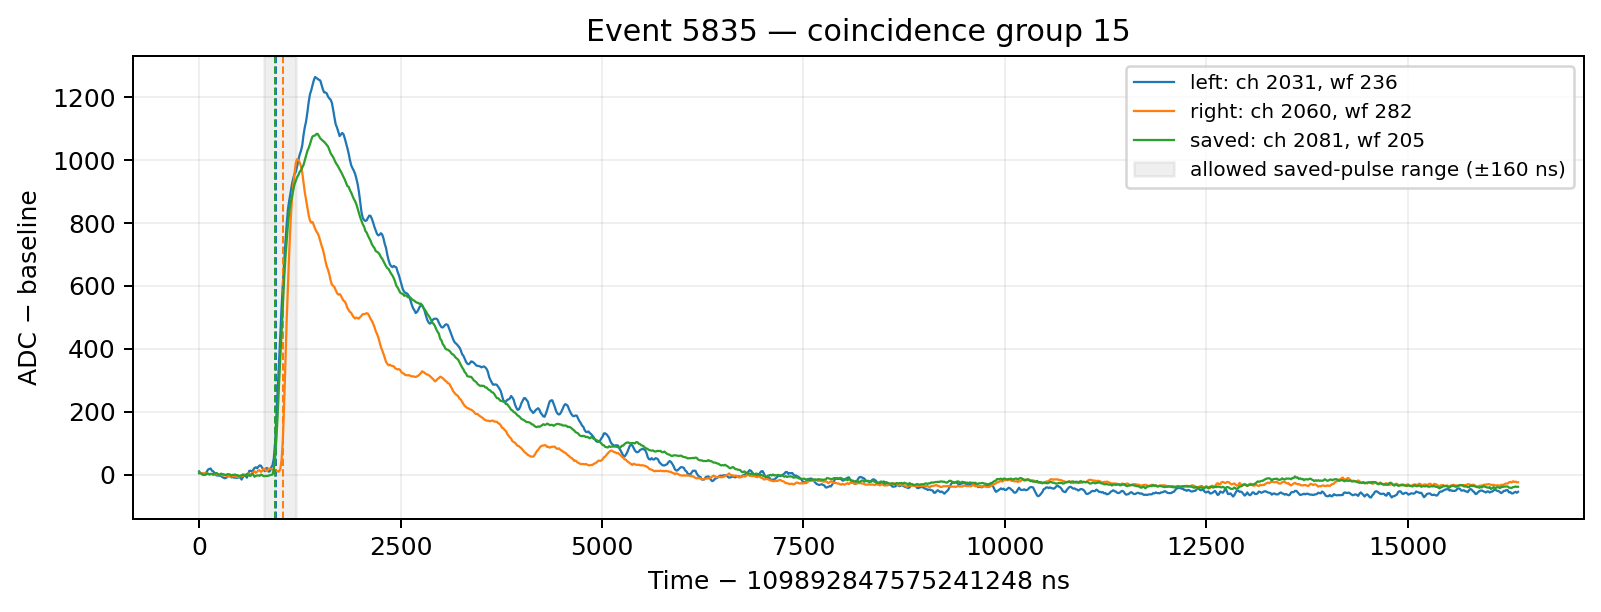


Group 16, CSV row 2336, event 371
  left : channel=2030, waveform_index=498, timestamp=109892830409773936 ns, pulse_start=58 ticks, pulse_time=109892830409774864 ns
  right: channel=2050, waveform_index=463, timestamp=109892830409773936 ns, pulse_start=58 ticks, pulse_time=109892830409774864 ns
  saved: channel=2080, waveform_index=401, timestamp=109892830409773936 ns, pulse_start=55 ticks, pulse_time=109892830409774816 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-48, calculated=-48


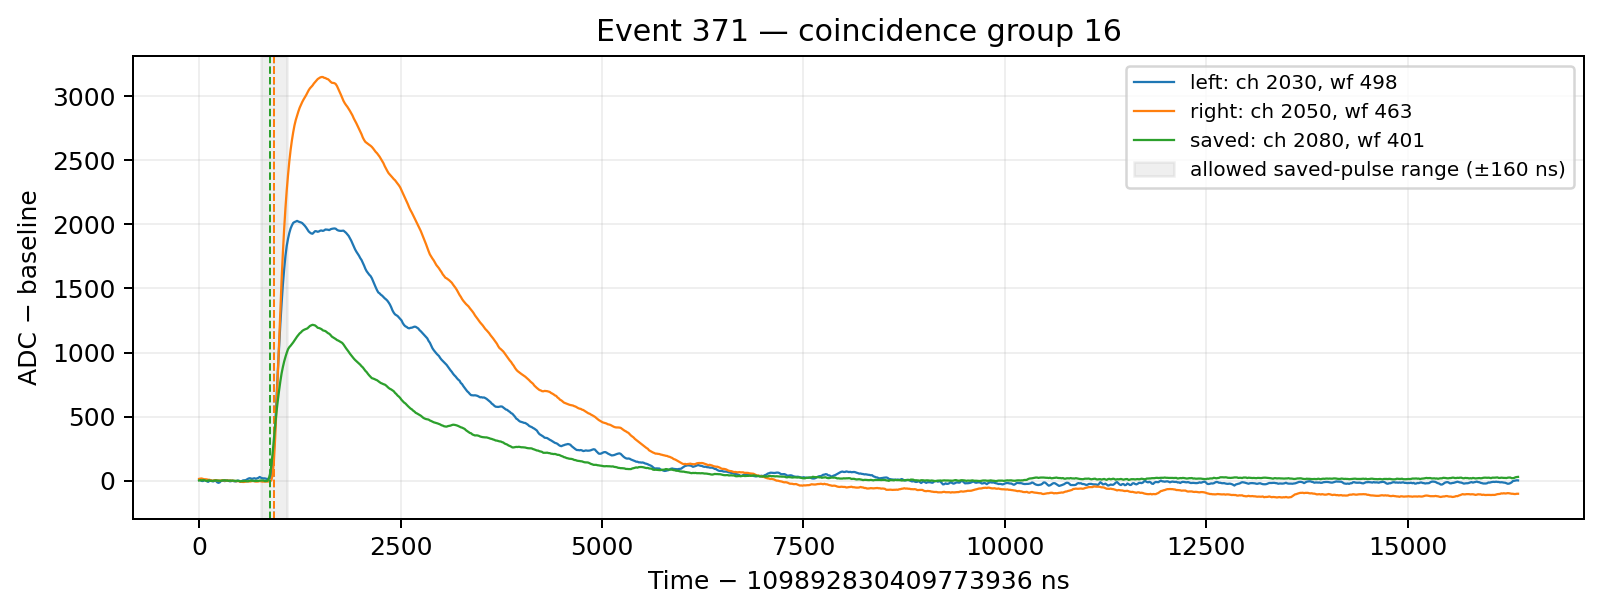


Group 17, CSV row 26458, event 4143
  left : channel=2031, waveform_index=311, timestamp=109892842259580400 ns, pulse_start=59 ticks, pulse_time=109892842259581344 ns
  right: channel=2050, waveform_index=116, timestamp=109892842259580400 ns, pulse_start=58 ticks, pulse_time=109892842259581328 ns
  saved: channel=2080, waveform_index=218, timestamp=109892842259580400 ns, pulse_start=57 ticks, pulse_time=109892842259581312 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=-16, calculated=-16


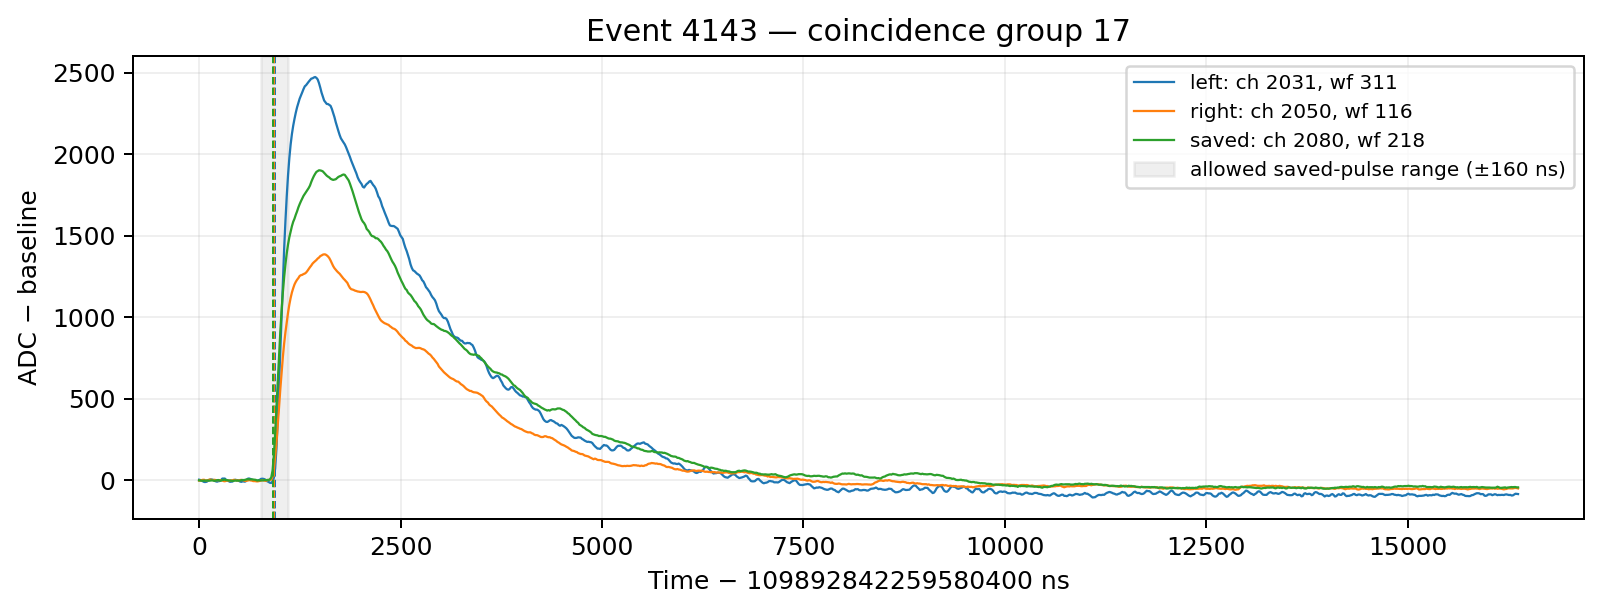


Group 18, CSV row 28500, event 4463
  left : channel=2031, waveform_index=194, timestamp=109892843264936064 ns, pulse_start=61 ticks, pulse_time=109892843264937040 ns
  right: channel=2060, waveform_index=229, timestamp=109892843264936064 ns, pulse_start=63 ticks, pulse_time=109892843264937072 ns
  saved: channel=2080, waveform_index=468, timestamp=109892843264936064 ns, pulse_start=60 ticks, pulse_time=109892843264937024 ns
  dt_ns_coinc: CSV=32, calculated=32
  dt_ns_save:  CSV=-16, calculated=-16


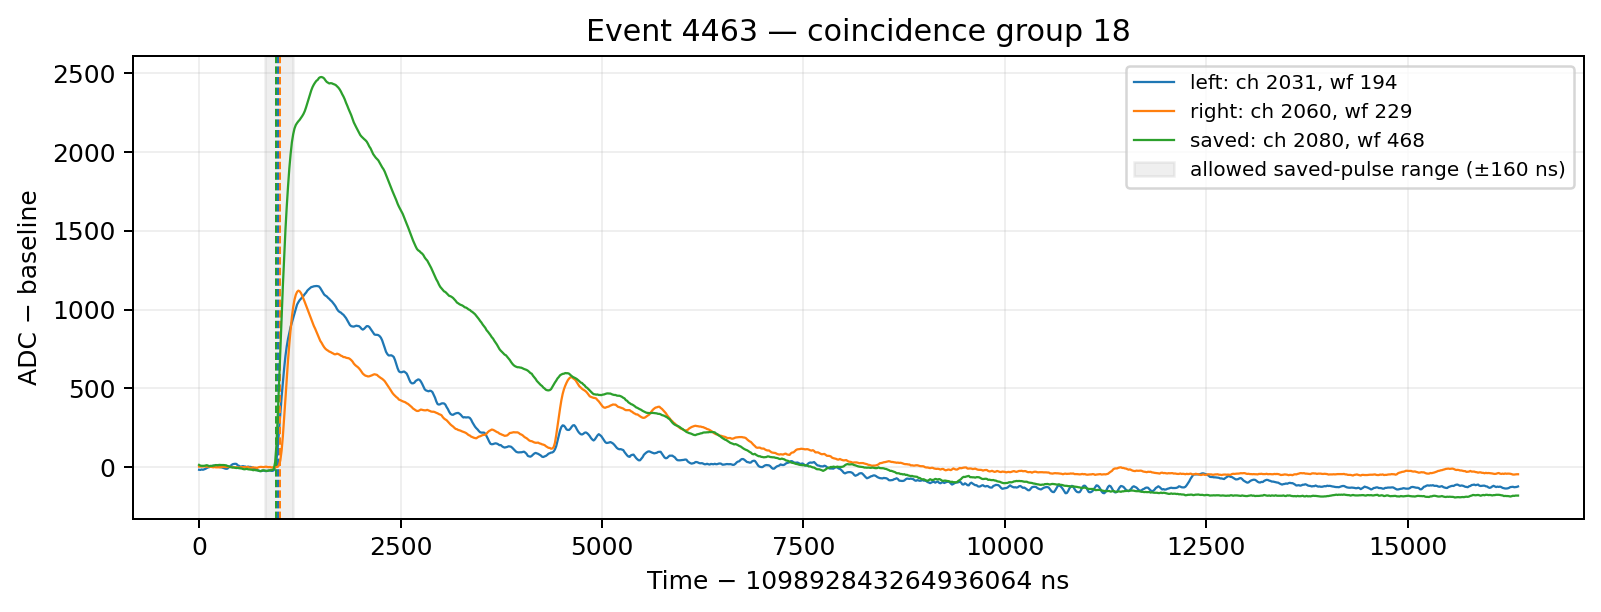


Group 19, CSV row 239, event 35
  left : channel=2040, waveform_index=327, timestamp=109892829354479424 ns, pulse_start=58 ticks, pulse_time=109892829354480352 ns
  right: channel=2050, waveform_index=232, timestamp=109892829354479424 ns, pulse_start=62 ticks, pulse_time=109892829354480416 ns
  saved: channel=2080, waveform_index=265, timestamp=109892829354479424 ns, pulse_start=58 ticks, pulse_time=109892829354480352 ns
  dt_ns_coinc: CSV=64, calculated=64
  dt_ns_save:  CSV=0, calculated=0


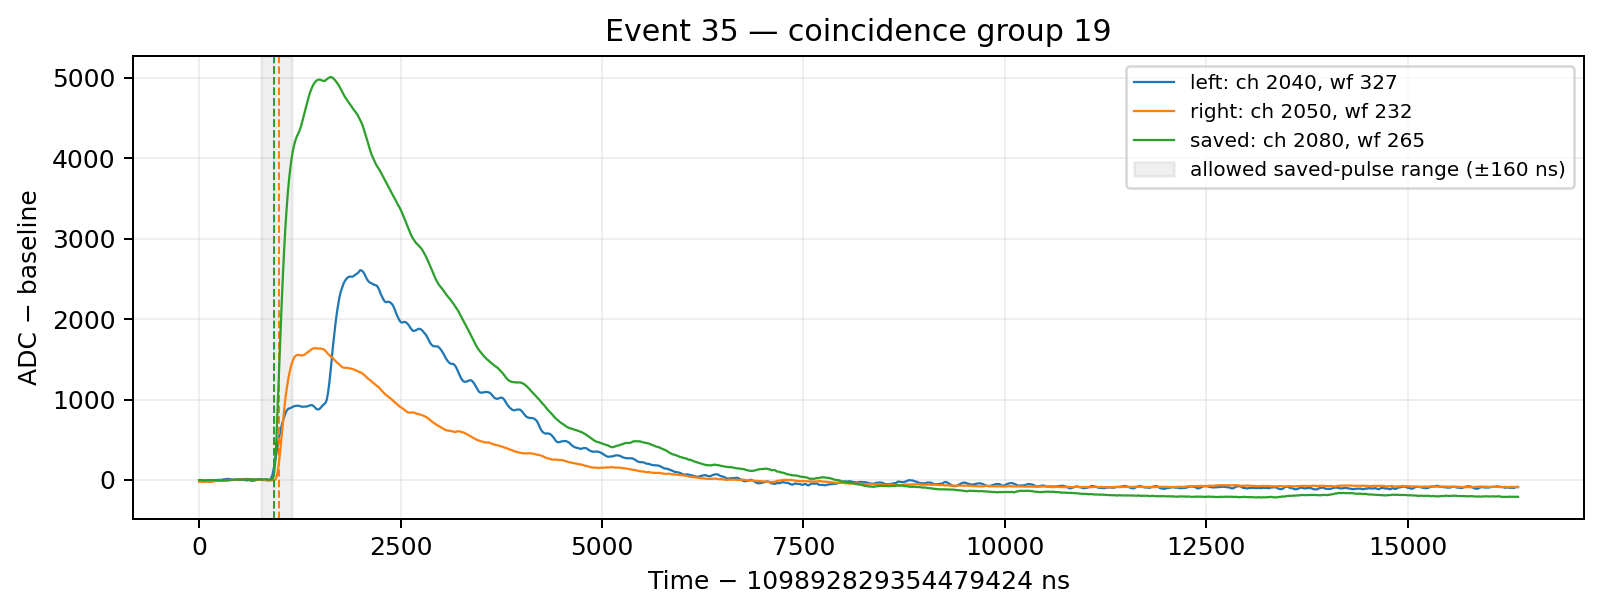


Group 20, CSV row 32106, event 5027
  left : channel=2040, waveform_index=291, timestamp=109892845037119376 ns, pulse_start=55 ticks, pulse_time=109892845037120256 ns
  right: channel=2050, waveform_index=420, timestamp=109892845037119360 ns, pulse_start=59 ticks, pulse_time=109892845037120304 ns
  saved: channel=2080, waveform_index=544, timestamp=109892845037119376 ns, pulse_start=58 ticks, pulse_time=109892845037120304 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=48, calculated=48


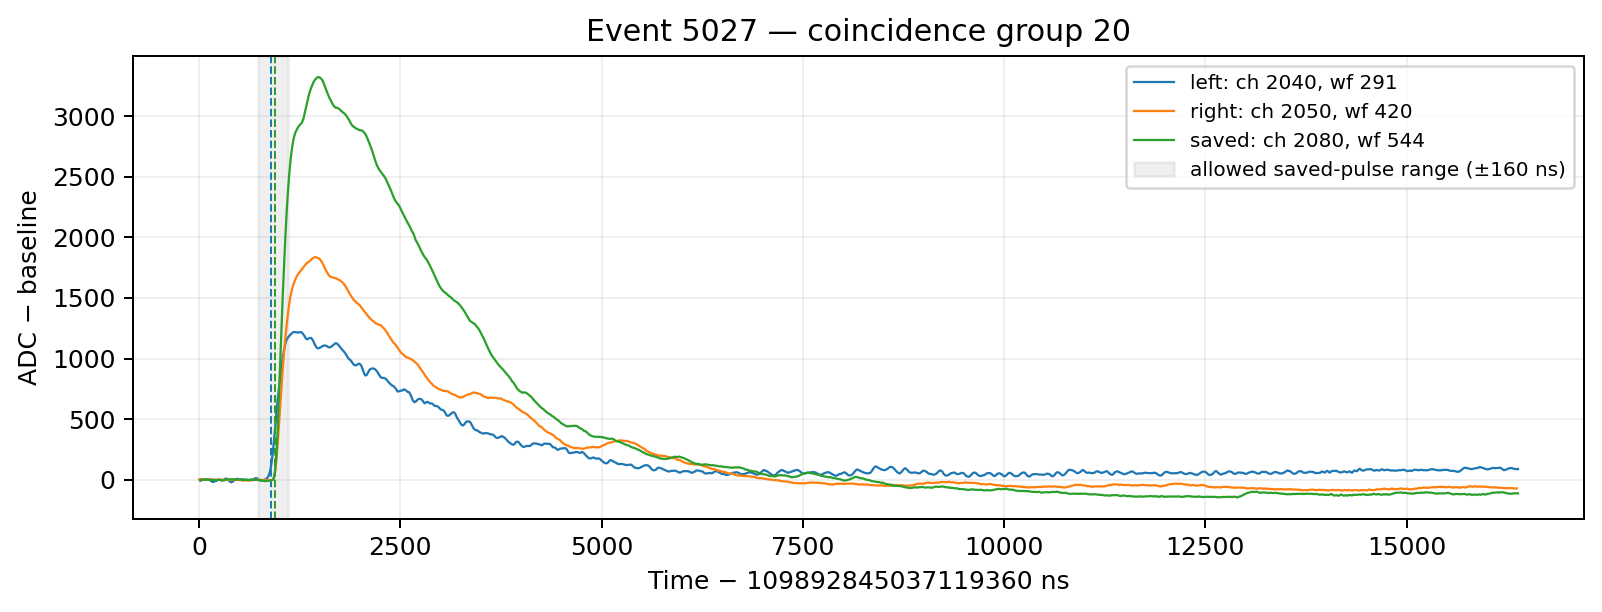


Group 21, CSV row 8792, event 1367
  left : channel=2030, waveform_index=567, timestamp=109892833539090944 ns, pulse_start=60 ticks, pulse_time=109892833539091904 ns
  right: channel=2050, waveform_index=150, timestamp=109892833539090944 ns, pulse_start=57 ticks, pulse_time=109892833539091856 ns
  saved: channel=2081, waveform_index=529, timestamp=109892833539090944 ns, pulse_start=56 ticks, pulse_time=109892833539091840 ns
  dt_ns_coinc: CSV=-48, calculated=-48
  dt_ns_save:  CSV=-16, calculated=-16


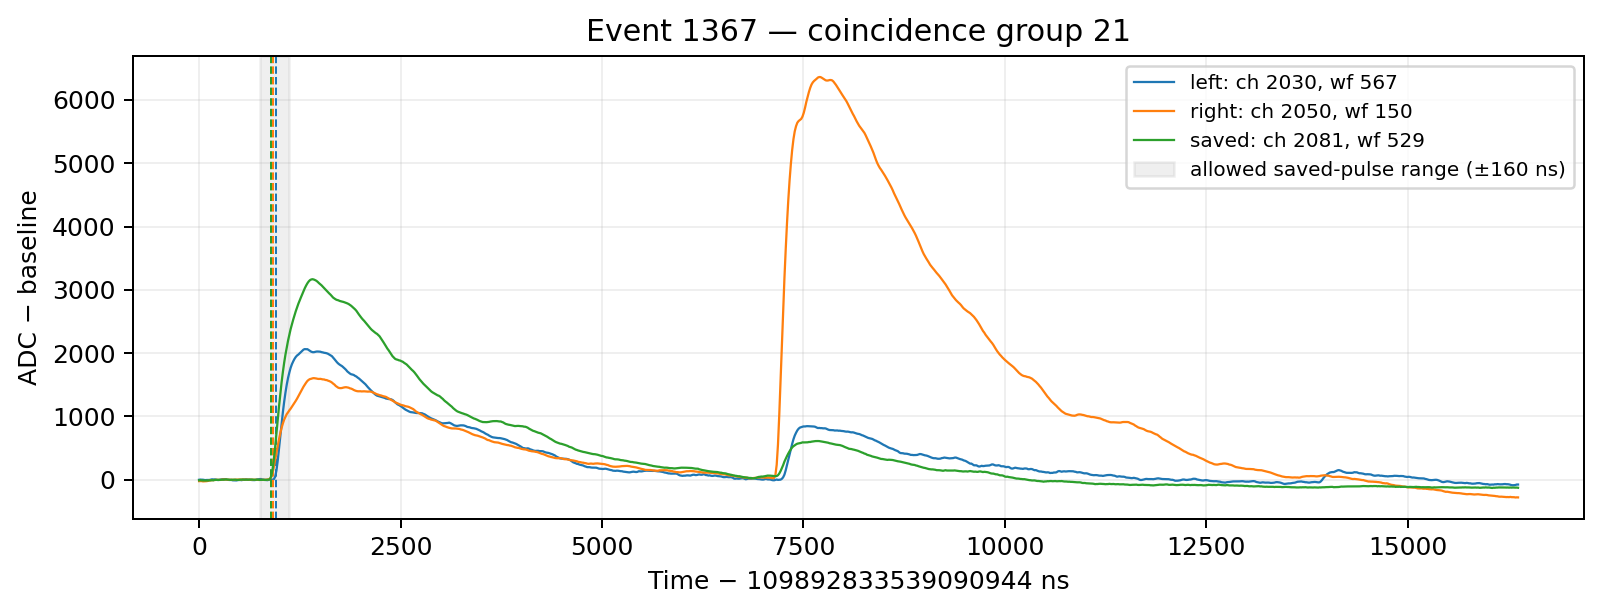


Group 22, CSV row 29409, event 4599
  left : channel=2041, waveform_index=252, timestamp=109892843692220960 ns, pulse_start=60 ticks, pulse_time=109892843692221920 ns
  right: channel=2051, waveform_index=297, timestamp=109892843692220960 ns, pulse_start=60 ticks, pulse_time=109892843692221920 ns
  saved: channel=2081, waveform_index=325, timestamp=109892843692220960 ns, pulse_start=59 ticks, pulse_time=109892843692221904 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


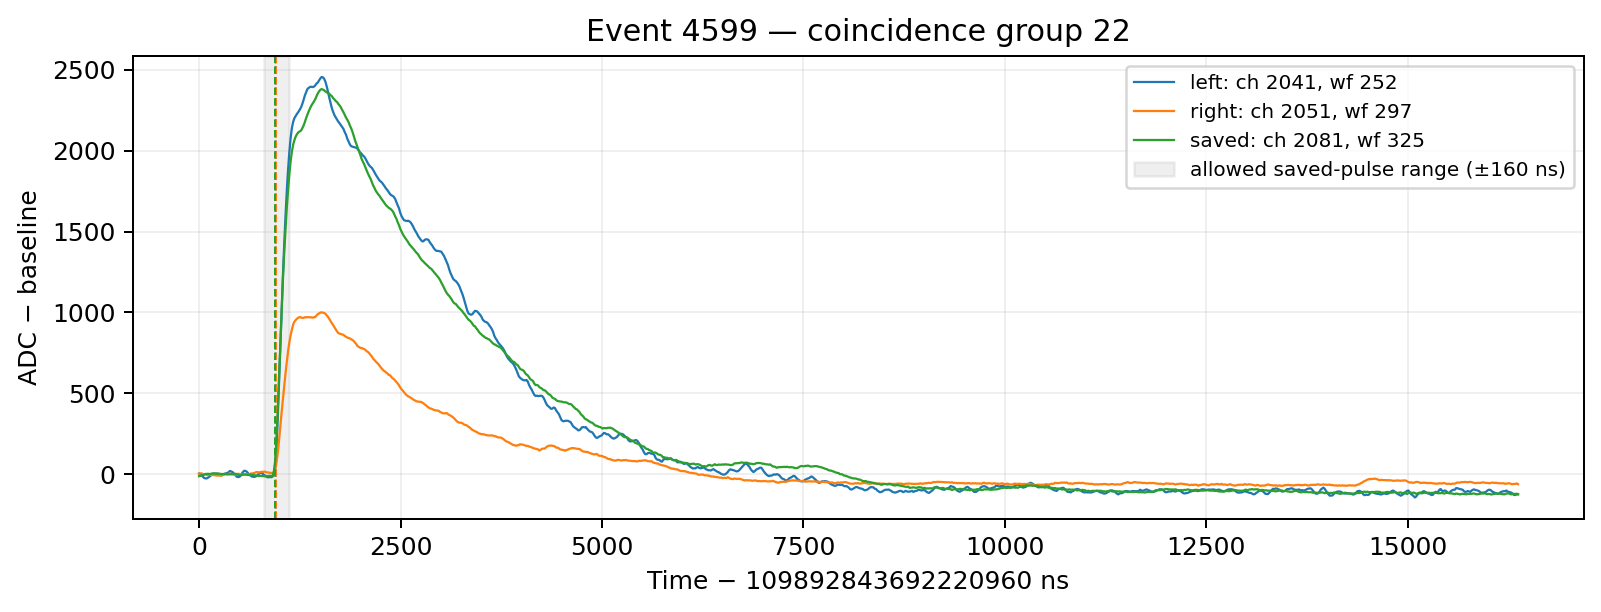


Group 23, CSV row 4929, event 765
  left : channel=2031, waveform_index=385, timestamp=109892831647945168 ns, pulse_start=58 ticks, pulse_time=109892831647946096 ns
  right: channel=2050, waveform_index=524, timestamp=109892831647945168 ns, pulse_start=58 ticks, pulse_time=109892831647946096 ns
  saved: channel=2080, waveform_index=561, timestamp=109892831647945184 ns, pulse_start=56 ticks, pulse_time=109892831647946080 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


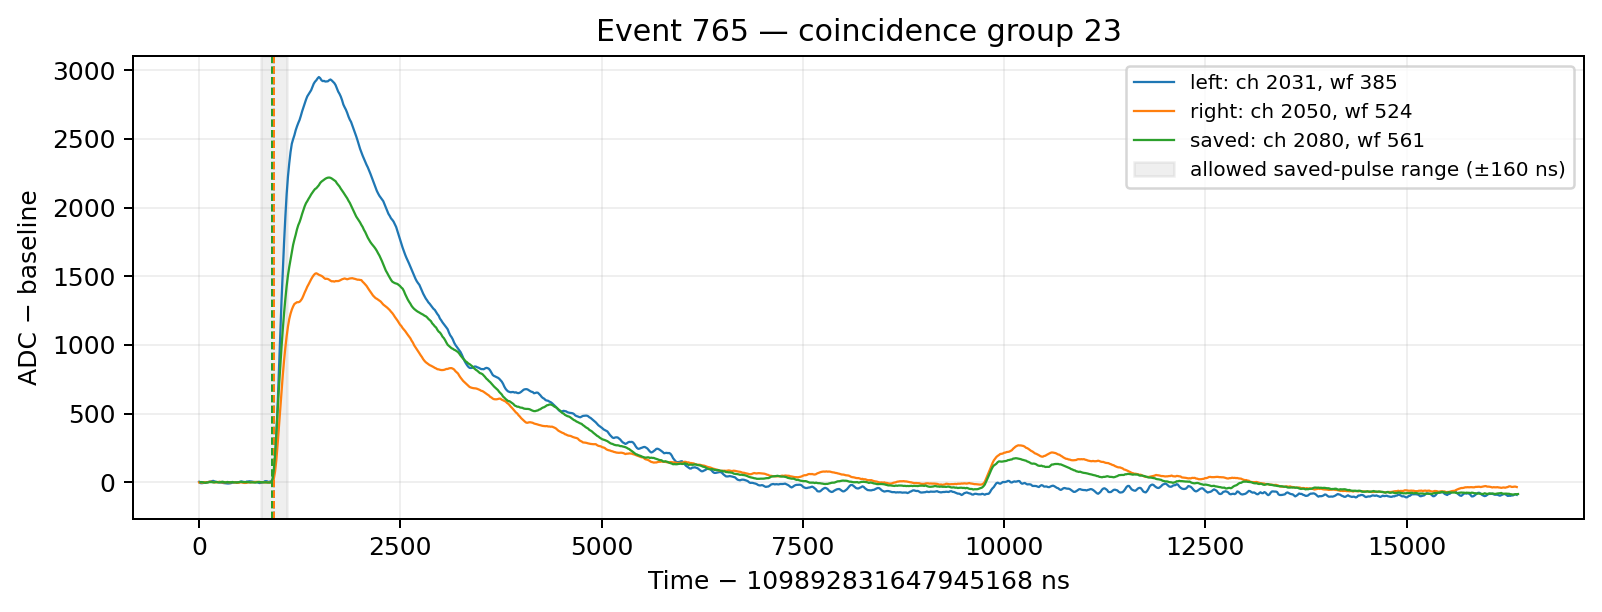


Group 24, CSV row 33356, event 5228
  left : channel=2040, waveform_index=449, timestamp=109892845668255744 ns, pulse_start=61 ticks, pulse_time=109892845668256720 ns
  right: channel=2051, waveform_index=499, timestamp=109892845668255744 ns, pulse_start=59 ticks, pulse_time=109892845668256688 ns
  saved: channel=2080, waveform_index=569, timestamp=109892845668255744 ns, pulse_start=59 ticks, pulse_time=109892845668256688 ns
  dt_ns_coinc: CSV=-32, calculated=-32
  dt_ns_save:  CSV=0, calculated=0


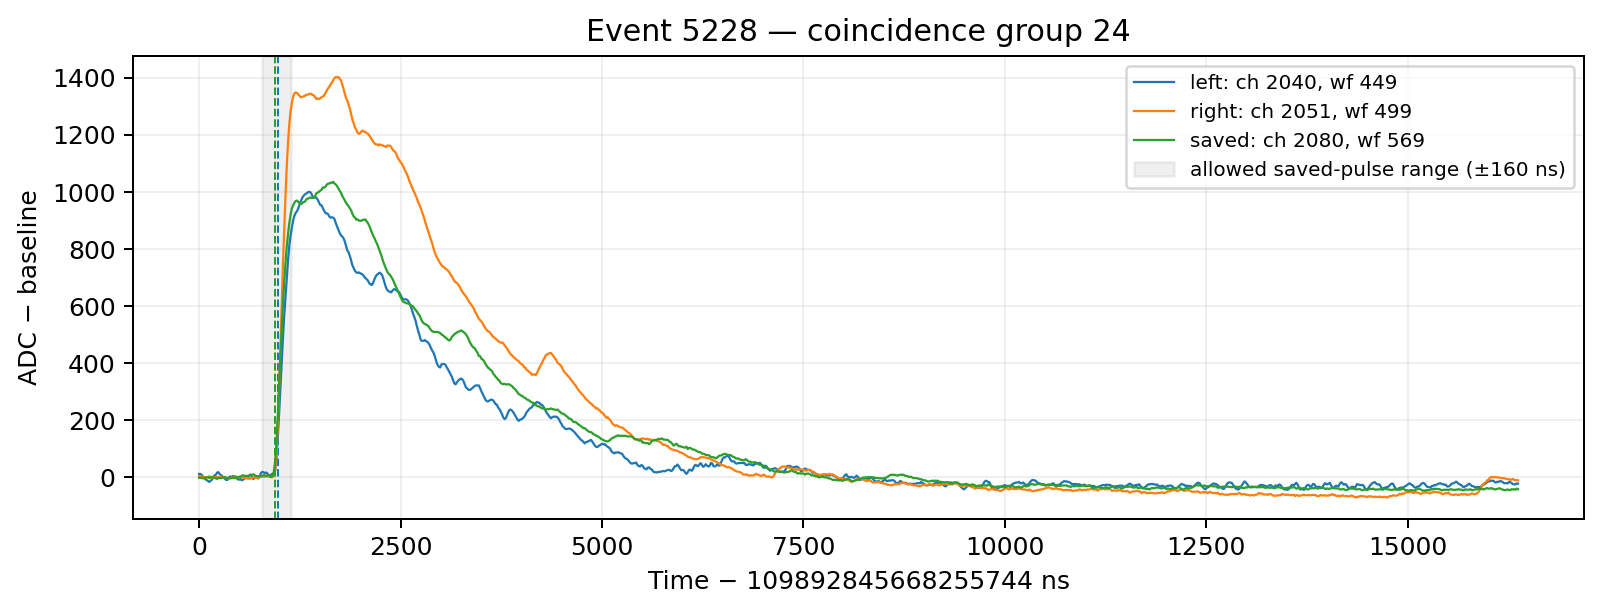


Group 25, CSV row 32914, event 5164
  left : channel=2030, waveform_index=516, timestamp=109892845467801088 ns, pulse_start=60 ticks, pulse_time=109892845467802048 ns
  right: channel=2060, waveform_index=412, timestamp=109892845467801088 ns, pulse_start=63 ticks, pulse_time=109892845467802096 ns
  saved: channel=2070, waveform_index=627, timestamp=109892845467801088 ns, pulse_start=63 ticks, pulse_time=109892845467802096 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=48, calculated=48


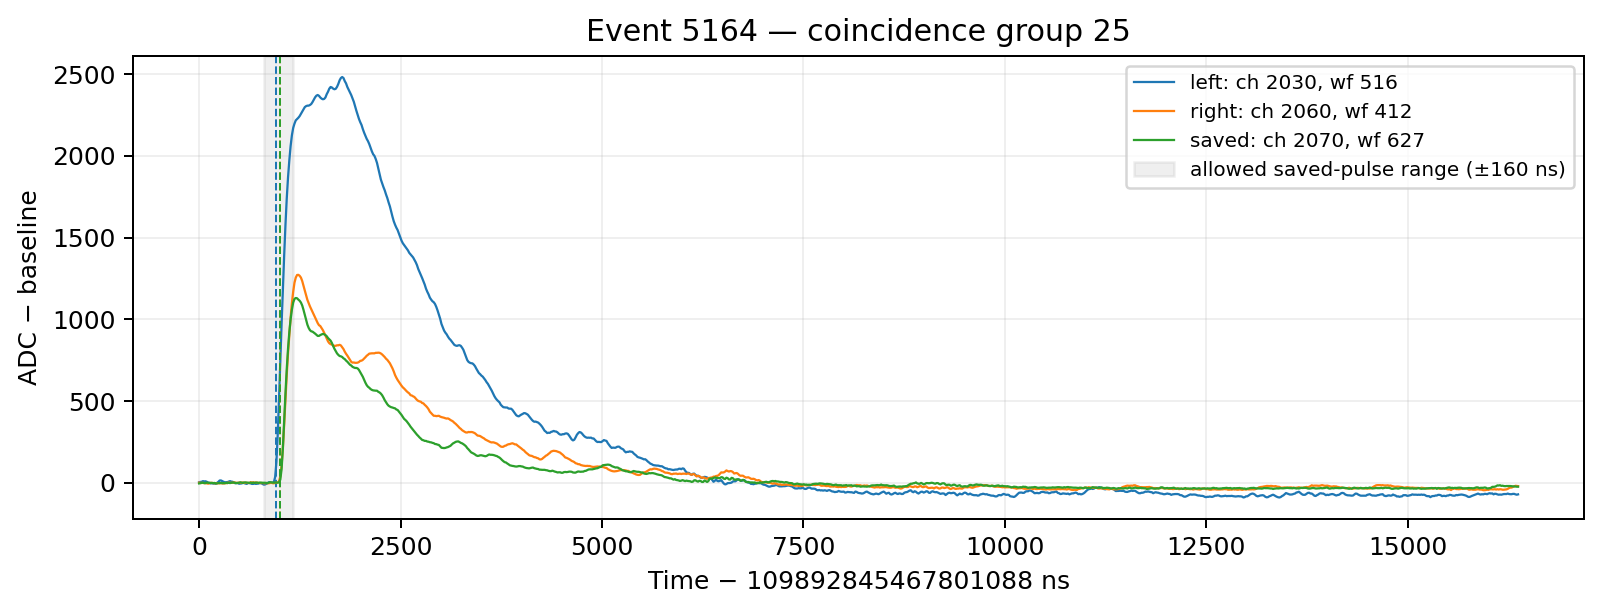


Group 26, CSV row 33096, event 5188
  left : channel=2030, waveform_index=406, timestamp=109892845542873520 ns, pulse_start=61 ticks, pulse_time=109892845542874496 ns
  right: channel=2060, waveform_index=296, timestamp=109892845542873520 ns, pulse_start=64 ticks, pulse_time=109892845542874544 ns
  saved: channel=2081, waveform_index=81, timestamp=109892845542873536 ns, pulse_start=59 ticks, pulse_time=109892845542874480 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=-16, calculated=-16


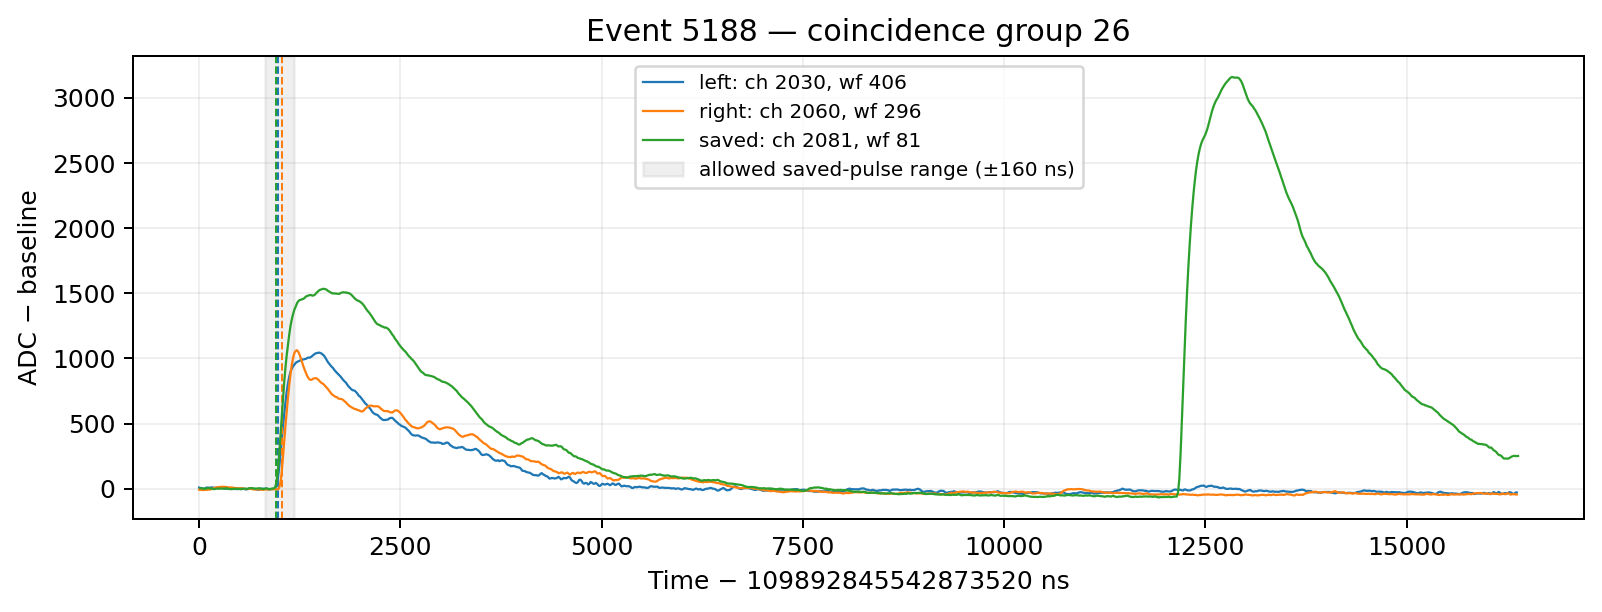


Group 27, CSV row 25047, event 3924
  left : channel=2040, waveform_index=356, timestamp=109892841571500592 ns, pulse_start=59 ticks, pulse_time=109892841571501536 ns
  right: channel=2050, waveform_index=256, timestamp=109892841571500592 ns, pulse_start=59 ticks, pulse_time=109892841571501536 ns
  saved: channel=2081, waveform_index=228, timestamp=109892841571500592 ns, pulse_start=58 ticks, pulse_time=109892841571501520 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


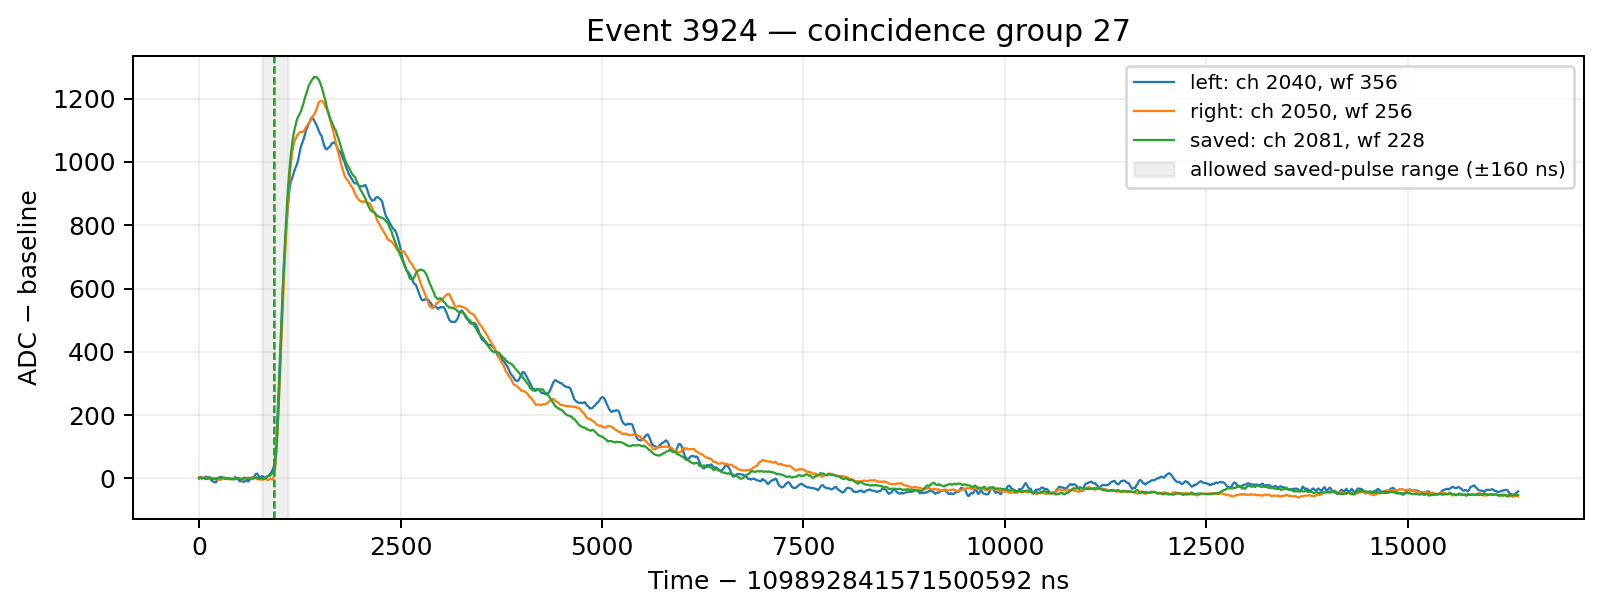


Group 28, CSV row 32881, event 5159
  left : channel=2031, waveform_index=166, timestamp=109892845451464864 ns, pulse_start=60 ticks, pulse_time=109892845451465824 ns
  right: channel=2050, waveform_index=426, timestamp=109892845451464880 ns, pulse_start=59 ticks, pulse_time=109892845451465824 ns
  saved: channel=2080, waveform_index=466, timestamp=109892845451464880 ns, pulse_start=58 ticks, pulse_time=109892845451465808 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


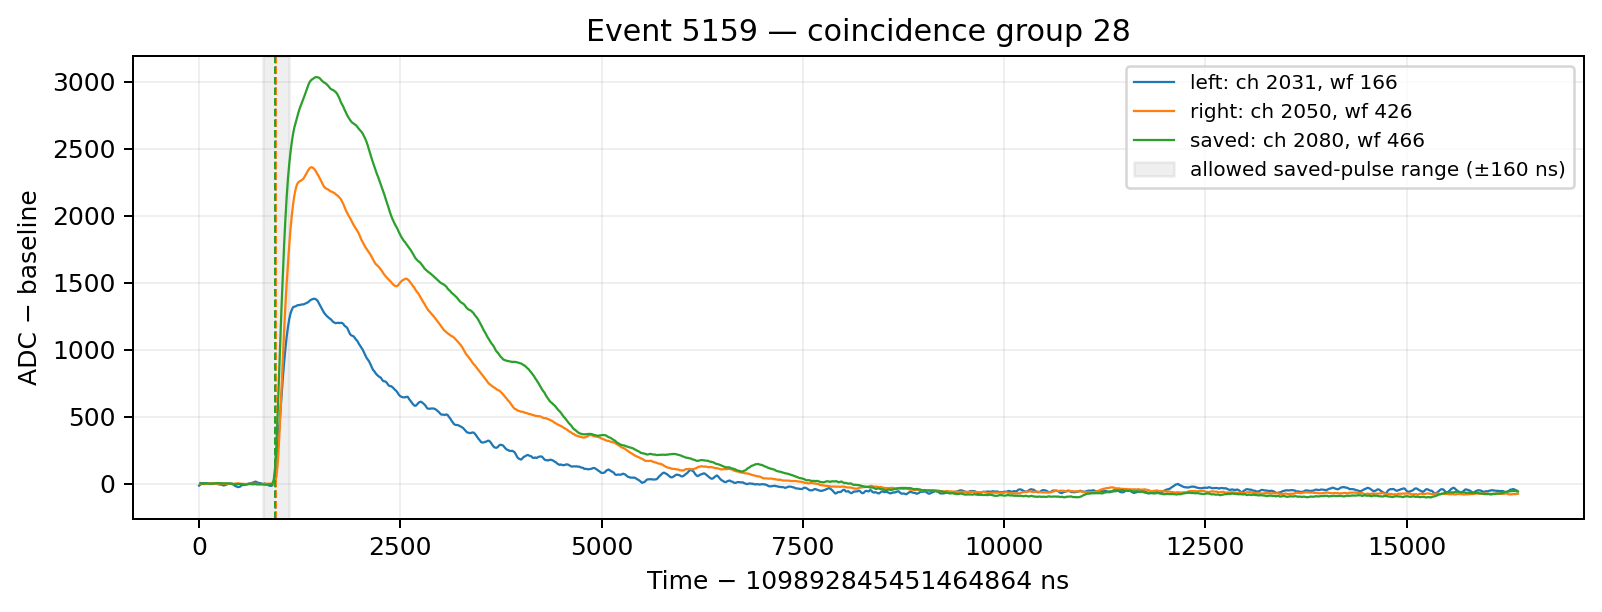


Group 29, CSV row 8213, event 1274
  left : channel=2040, waveform_index=460, timestamp=109892833247082672 ns, pulse_start=60 ticks, pulse_time=109892833247083632 ns
  right: channel=2060, waveform_index=228, timestamp=109892833247082672 ns, pulse_start=63 ticks, pulse_time=109892833247083680 ns
  saved: channel=2080, waveform_index=397, timestamp=109892833247082672 ns, pulse_start=57 ticks, pulse_time=109892833247083584 ns
  dt_ns_coinc: CSV=48, calculated=48
  dt_ns_save:  CSV=-48, calculated=-48


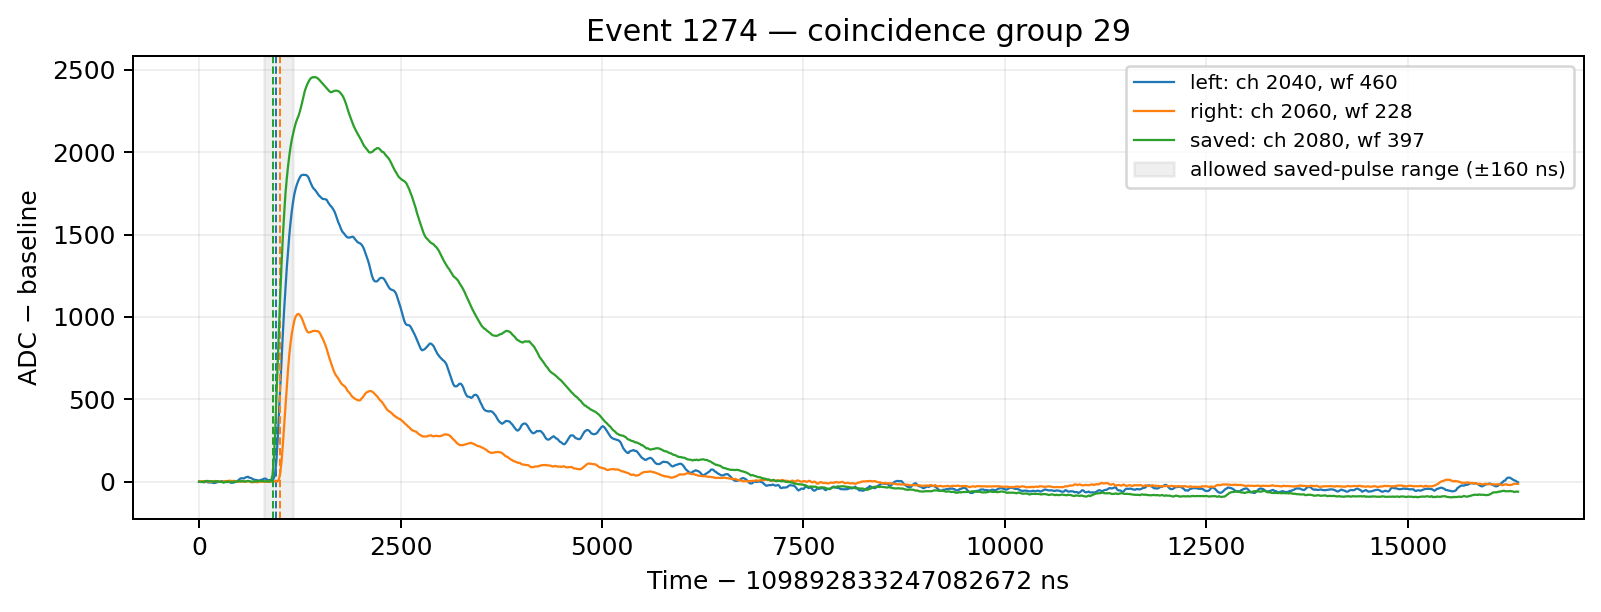


Group 30, CSV row 25284, event 3958
  left : channel=2040, waveform_index=215, timestamp=109892841679005920 ns, pulse_start=63 ticks, pulse_time=109892841679006928 ns
  right: channel=2050, waveform_index=268, timestamp=109892841679005920 ns, pulse_start=58 ticks, pulse_time=109892841679006848 ns
  saved: channel=2081, waveform_index=534, timestamp=109892841679005920 ns, pulse_start=57 ticks, pulse_time=109892841679006832 ns
  dt_ns_coinc: CSV=-80, calculated=-80
  dt_ns_save:  CSV=-16, calculated=-16


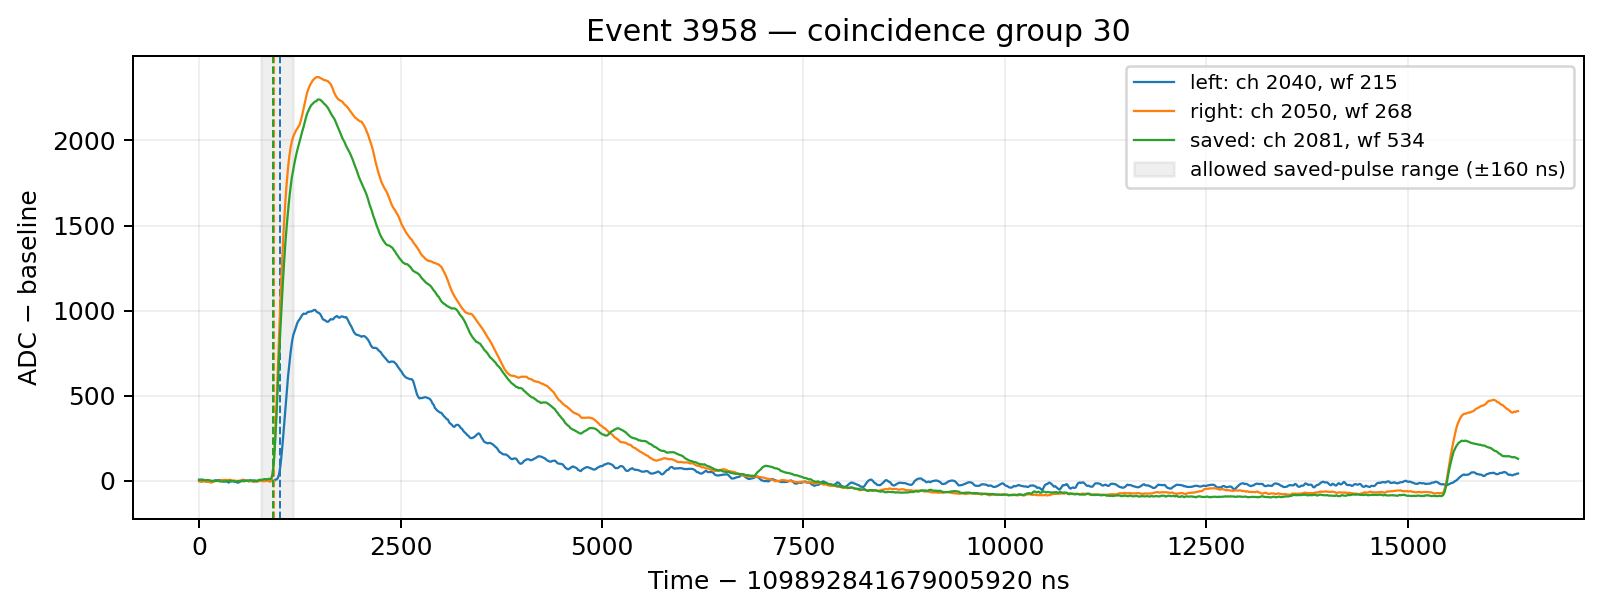


Group 31, CSV row 23419, event 3657
  left : channel=2040, waveform_index=98, timestamp=109892840733231248 ns, pulse_start=60 ticks, pulse_time=109892840733232208 ns
  right: channel=2051, waveform_index=418, timestamp=109892840733231248 ns, pulse_start=60 ticks, pulse_time=109892840733232208 ns
  saved: channel=2080, waveform_index=468, timestamp=109892840733231248 ns, pulse_start=59 ticks, pulse_time=109892840733232192 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


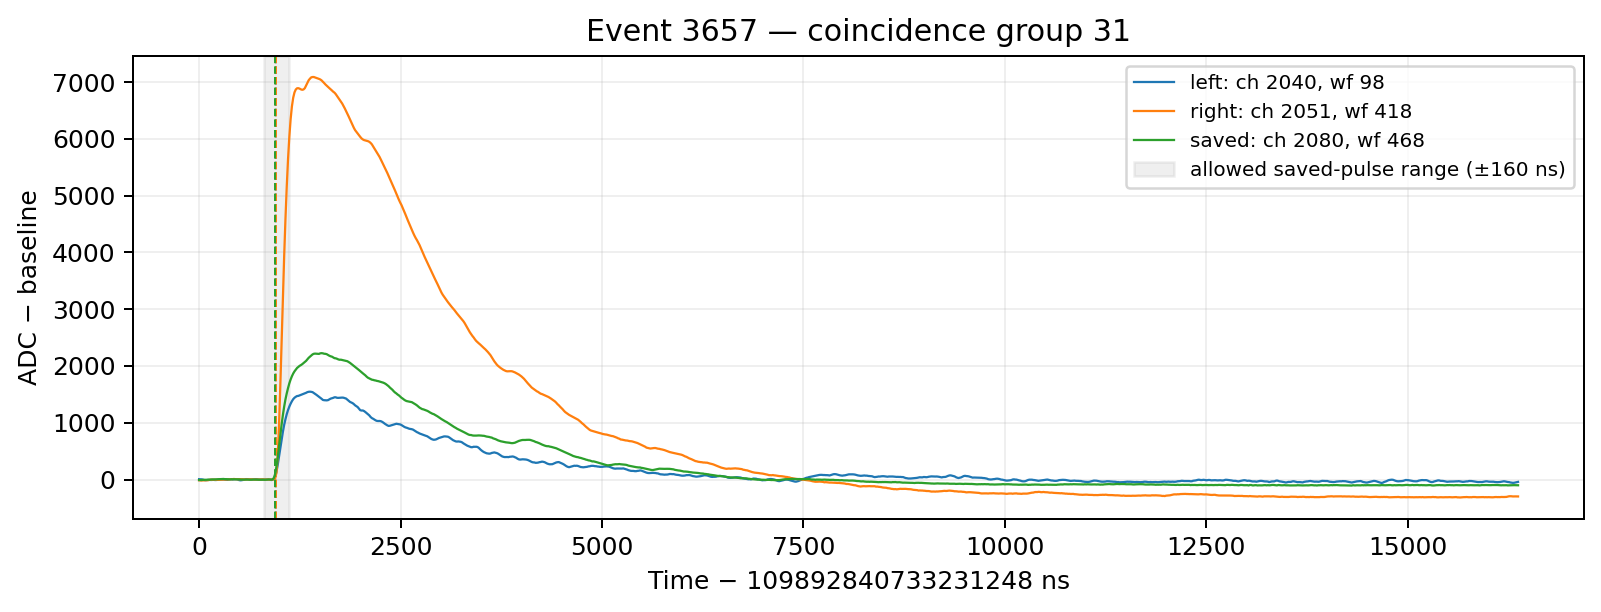


Group 32, CSV row 27596, event 4316
  left : channel=2040, waveform_index=687, timestamp=109892842803163120 ns, pulse_start=61 ticks, pulse_time=109892842803164096 ns
  right: channel=2061, waveform_index=179, timestamp=109892842803163120 ns, pulse_start=62 ticks, pulse_time=109892842803164112 ns
  saved: channel=2071, waveform_index=728, timestamp=109892842803163120 ns, pulse_start=65 ticks, pulse_time=109892842803164160 ns
  dt_ns_coinc: CSV=16, calculated=16
  dt_ns_save:  CSV=64, calculated=64


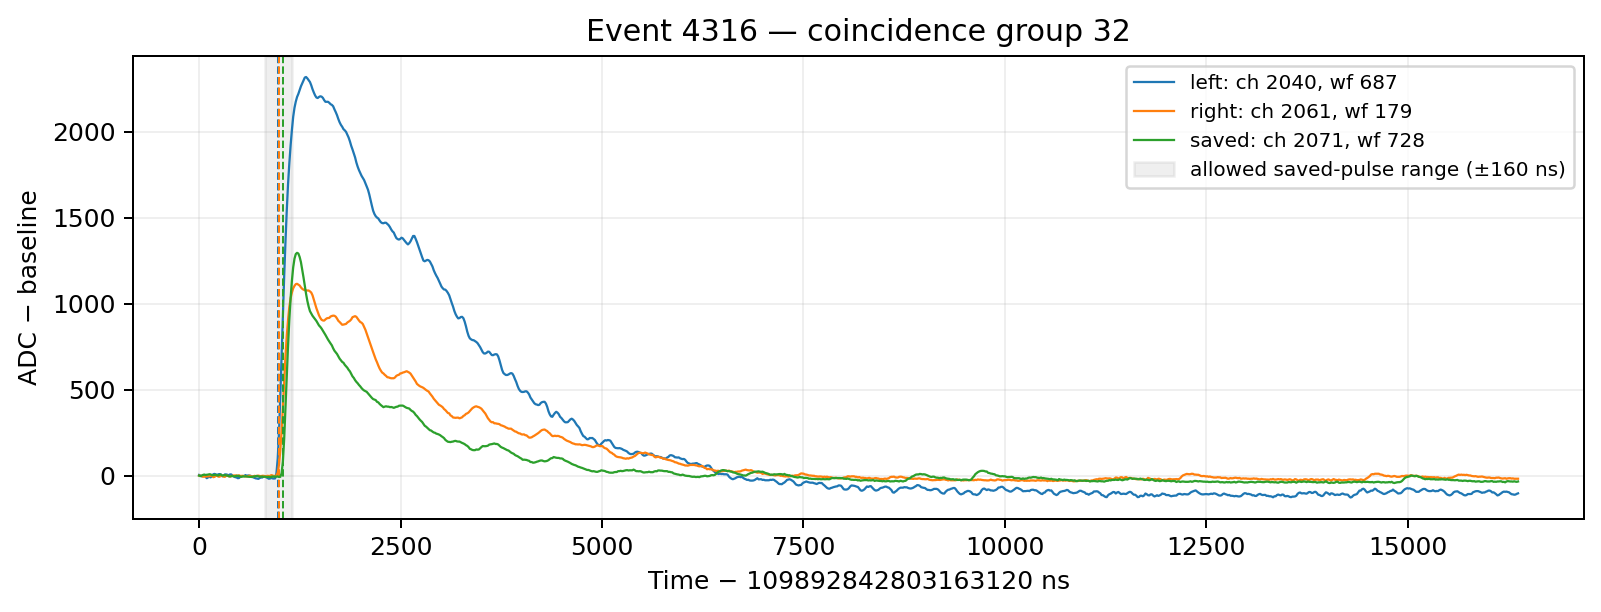


Group 33, CSV row 29311, event 4585
  left : channel=2030, waveform_index=161, timestamp=109892843647945696 ns, pulse_start=59 ticks, pulse_time=109892843647946640 ns
  right: channel=2060, waveform_index=419, timestamp=109892843647945696 ns, pulse_start=64 ticks, pulse_time=109892843647946720 ns
  saved: channel=2080, waveform_index=499, timestamp=109892843647945696 ns, pulse_start=58 ticks, pulse_time=109892843647946624 ns
  dt_ns_coinc: CSV=80, calculated=80
  dt_ns_save:  CSV=-16, calculated=-16


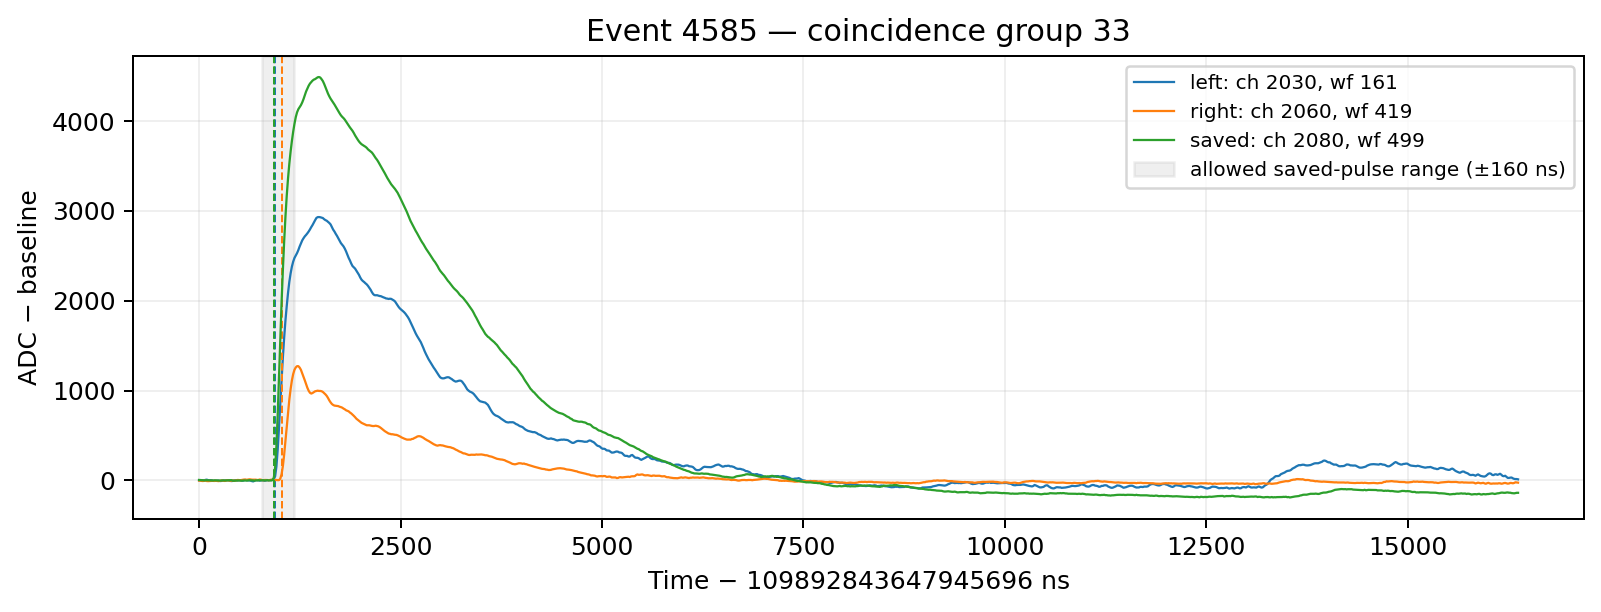


Group 34, CSV row 22728, event 3538
  left : channel=2030, waveform_index=122, timestamp=109892840358700624 ns, pulse_start=59 ticks, pulse_time=109892840358701568 ns
  right: channel=2060, waveform_index=206, timestamp=109892840358700624 ns, pulse_start=64 ticks, pulse_time=109892840358701648 ns
  saved: channel=2081, waveform_index=85, timestamp=109892840358700624 ns, pulse_start=58 ticks, pulse_time=109892840358701552 ns
  dt_ns_coinc: CSV=80, calculated=80
  dt_ns_save:  CSV=-16, calculated=-16


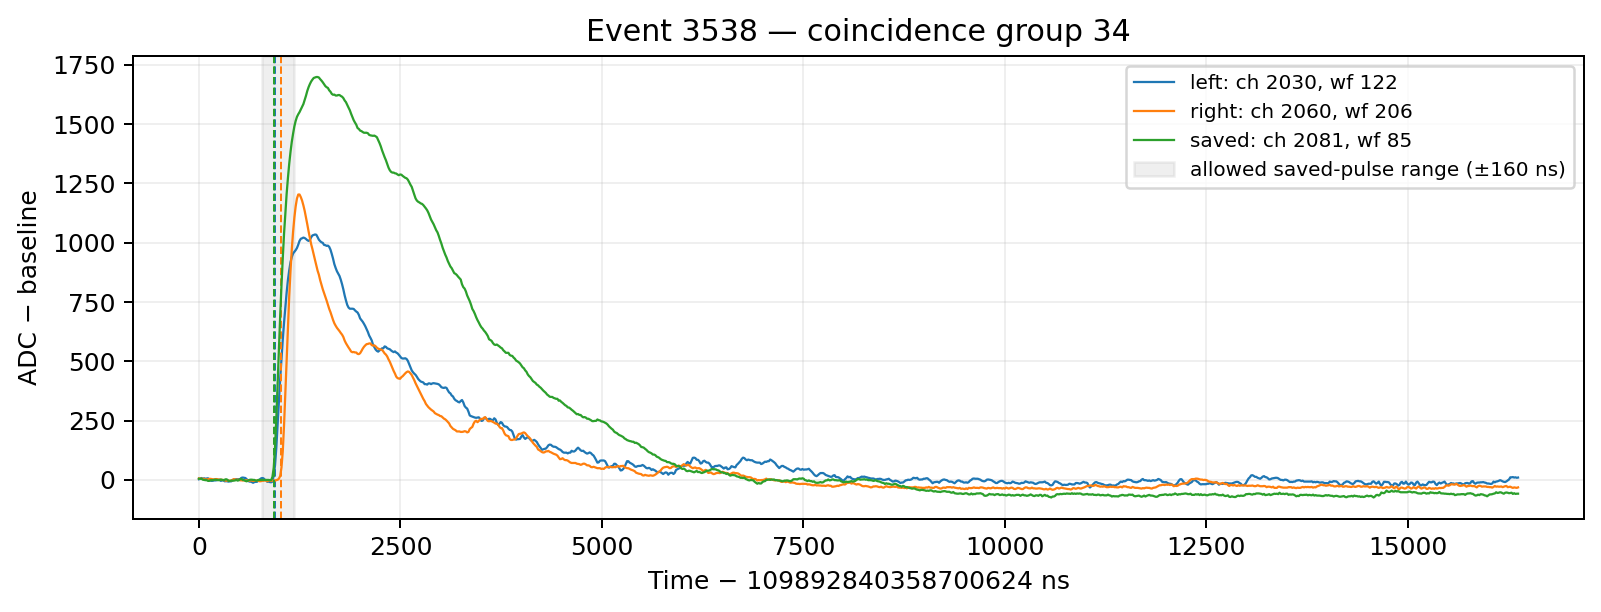


Group 35, CSV row 6277, event 976
  left : channel=2030, waveform_index=269, timestamp=109892832310844160 ns, pulse_start=60 ticks, pulse_time=109892832310845120 ns
  right: channel=2060, waveform_index=353, timestamp=109892832310844160 ns, pulse_start=60 ticks, pulse_time=109892832310845120 ns
  saved: channel=2081, waveform_index=98, timestamp=109892832310844160 ns, pulse_start=59 ticks, pulse_time=109892832310845104 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


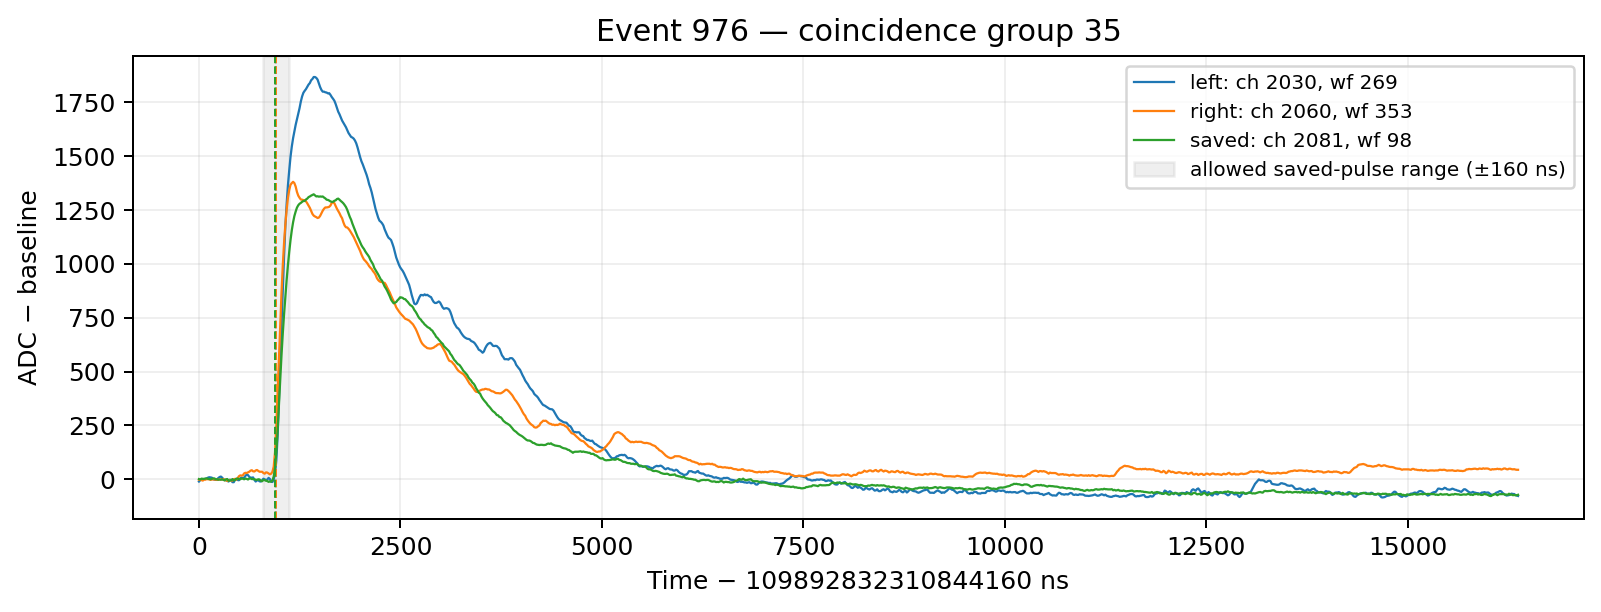


Group 36, CSV row 22139, event 3460
  left : channel=2041, waveform_index=411, timestamp=109892840114035248 ns, pulse_start=59 ticks, pulse_time=109892840114036192 ns
  right: channel=2060, waveform_index=210, timestamp=109892840114035248 ns, pulse_start=64 ticks, pulse_time=109892840114036272 ns
  saved: channel=2080, waveform_index=360, timestamp=109892840114035264 ns, pulse_start=58 ticks, pulse_time=109892840114036192 ns
  dt_ns_coinc: CSV=80, calculated=80
  dt_ns_save:  CSV=0, calculated=0


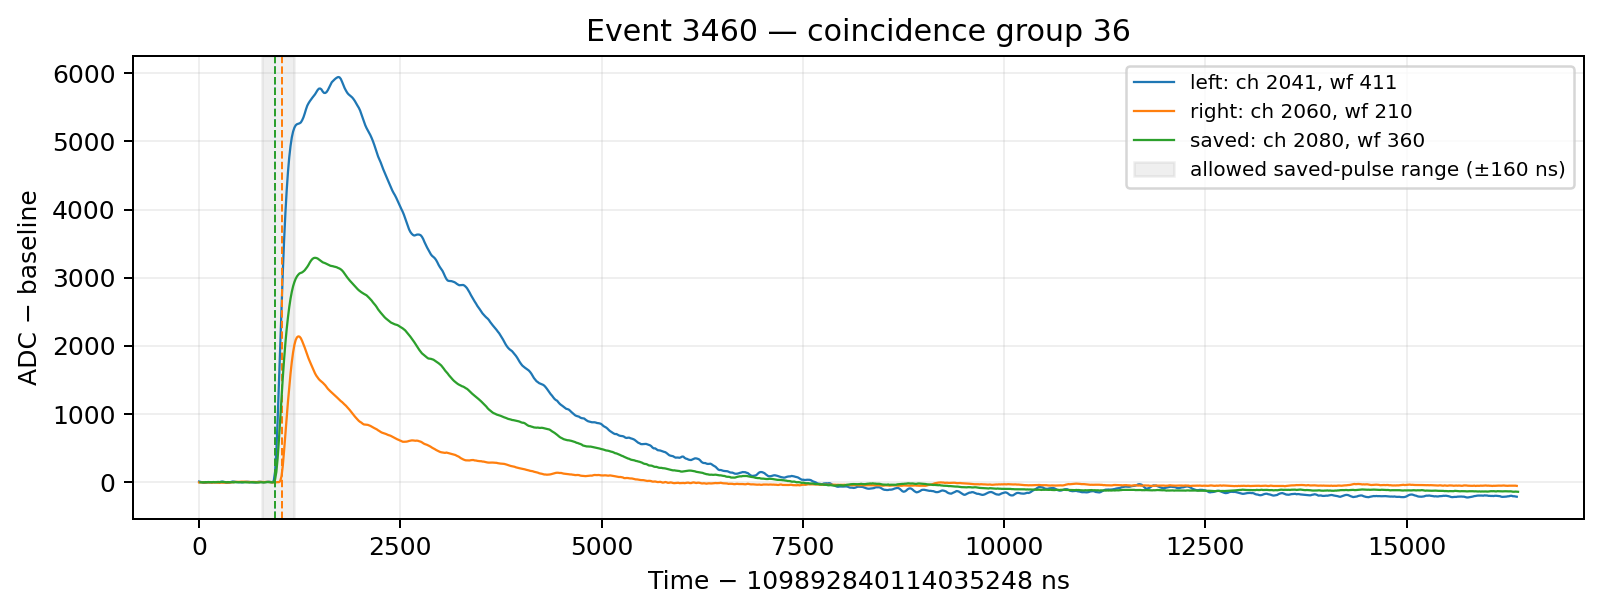


Group 37, CSV row 2189, event 350
  left : channel=2041, waveform_index=375, timestamp=109892830343758864 ns, pulse_start=60 ticks, pulse_time=109892830343759824 ns
  right: channel=2060, waveform_index=276, timestamp=109892830343758864 ns, pulse_start=64 ticks, pulse_time=109892830343759888 ns
  saved: channel=2081, waveform_index=518, timestamp=109892830343758880 ns, pulse_start=59 ticks, pulse_time=109892830343759824 ns
  dt_ns_coinc: CSV=64, calculated=64
  dt_ns_save:  CSV=0, calculated=0


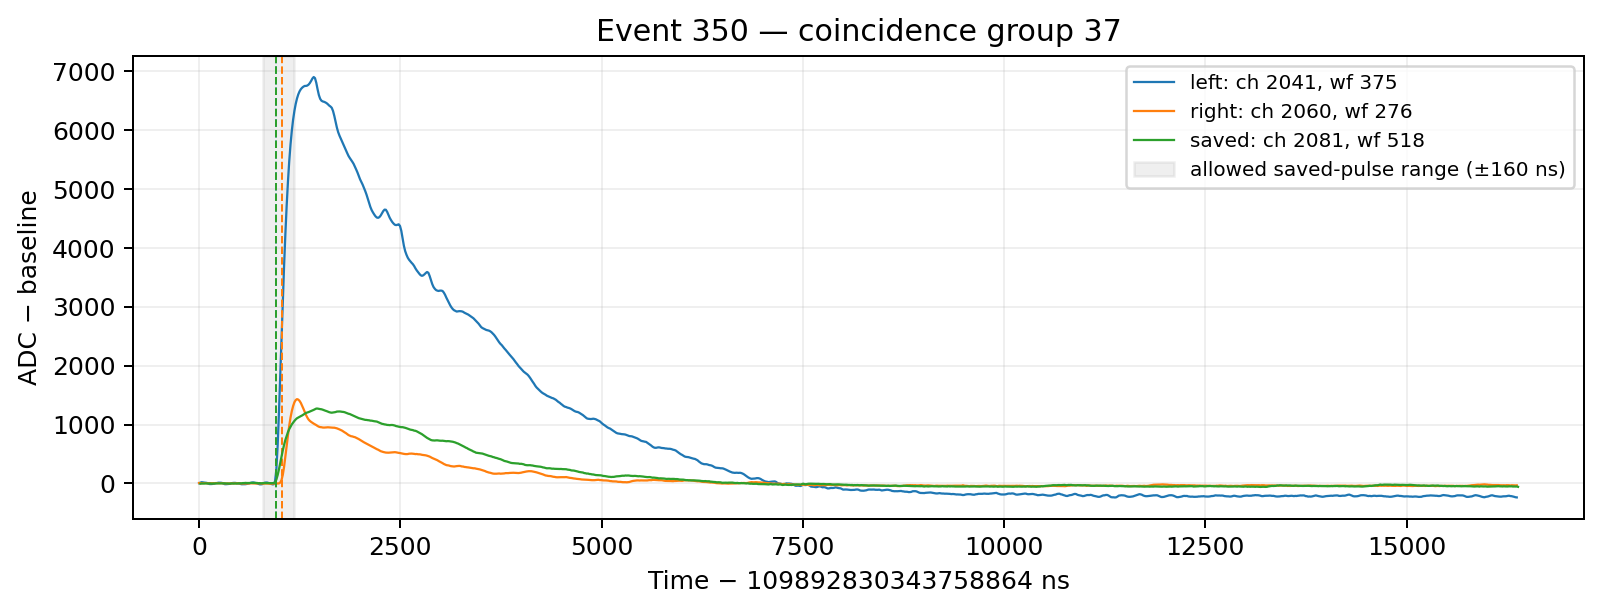


Group 38, CSV row 7058, event 1099
  left : channel=2031, waveform_index=466, timestamp=109892832697843504 ns, pulse_start=59 ticks, pulse_time=109892832697844448 ns
  right: channel=2051, waveform_index=129, timestamp=109892832697843520 ns, pulse_start=58 ticks, pulse_time=109892832697844448 ns
  saved: channel=2081, waveform_index=522, timestamp=109892832697843520 ns, pulse_start=59 ticks, pulse_time=109892832697844464 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=16, calculated=16


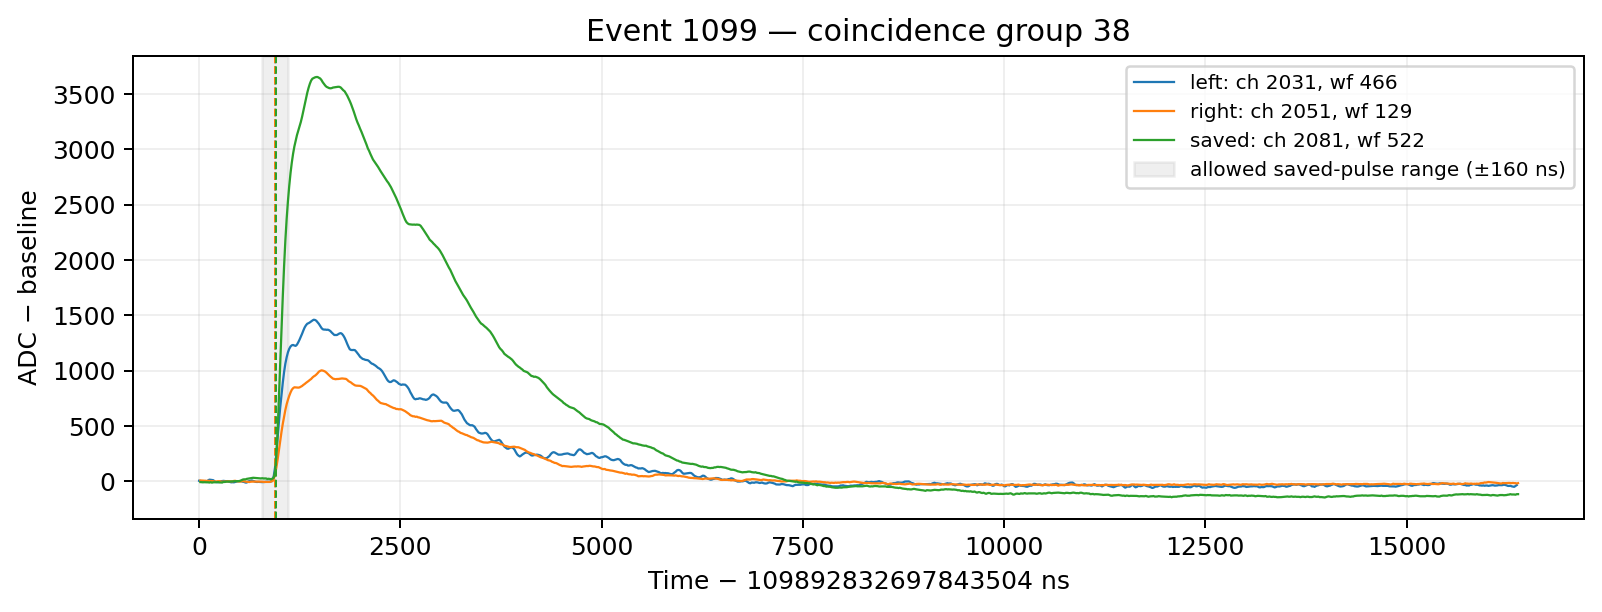


Group 39, CSV row 602, event 96
  left : channel=2031, waveform_index=335, timestamp=109892829545924592 ns, pulse_start=62 ticks, pulse_time=109892829545925584 ns
  right: channel=2050, waveform_index=129, timestamp=109892829545924608 ns, pulse_start=60 ticks, pulse_time=109892829545925568 ns
  saved: channel=2080, waveform_index=166, timestamp=109892829545924608 ns, pulse_start=59 ticks, pulse_time=109892829545925552 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=-16, calculated=-16


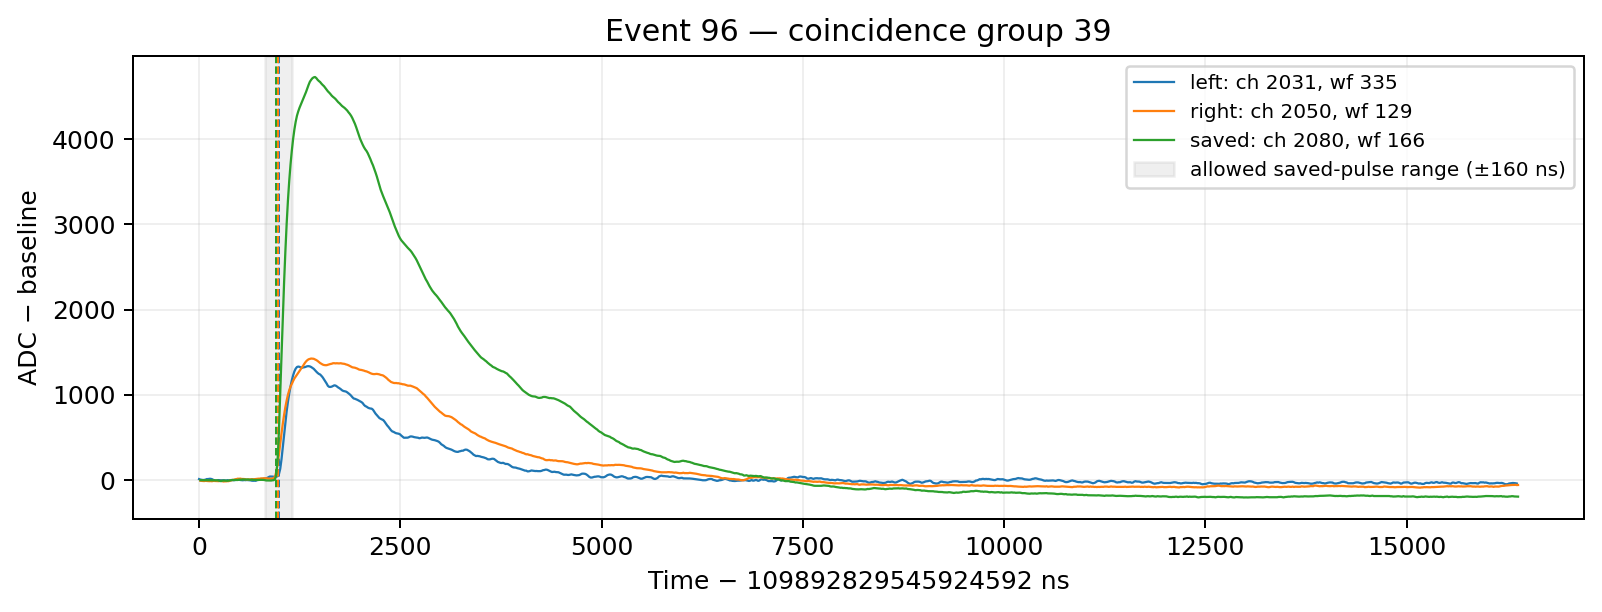


Group 40, CSV row 24333, event 3805
  left : channel=2040, waveform_index=211, timestamp=109892841197622576 ns, pulse_start=60 ticks, pulse_time=109892841197623536 ns
  right: channel=2060, waveform_index=170, timestamp=109892841197622576 ns, pulse_start=64 ticks, pulse_time=109892841197623600 ns
  saved: channel=2081, waveform_index=48, timestamp=109892841197622592 ns, pulse_start=58 ticks, pulse_time=109892841197623520 ns
  dt_ns_coinc: CSV=64, calculated=64
  dt_ns_save:  CSV=-16, calculated=-16


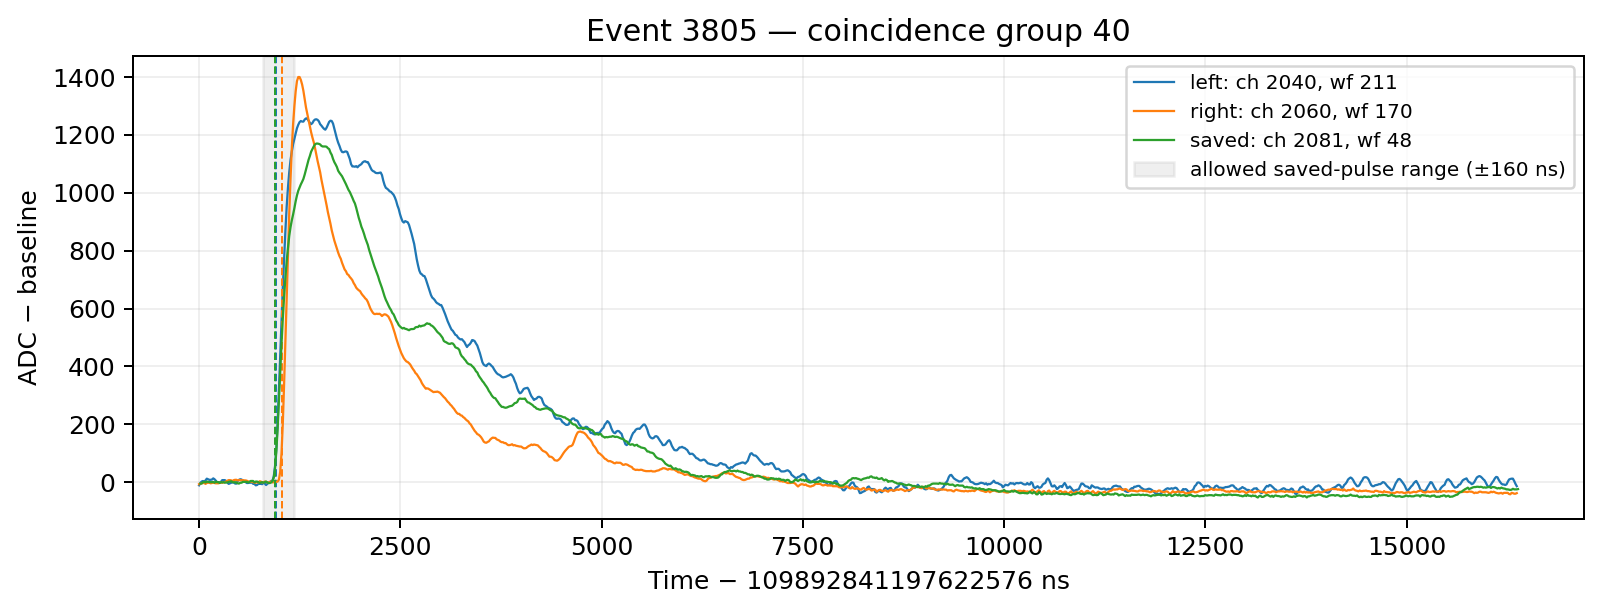


Group 41, CSV row 34121, event 5364
  left : channel=2030, waveform_index=144, timestamp=109892846095360352 ns, pulse_start=60 ticks, pulse_time=109892846095361312 ns
  right: channel=2050, waveform_index=523, timestamp=109892846095360352 ns, pulse_start=58 ticks, pulse_time=109892846095361280 ns
  saved: channel=2081, waveform_index=595, timestamp=109892846095360352 ns, pulse_start=59 ticks, pulse_time=109892846095361296 ns
  dt_ns_coinc: CSV=-32, calculated=-32
  dt_ns_save:  CSV=16, calculated=16


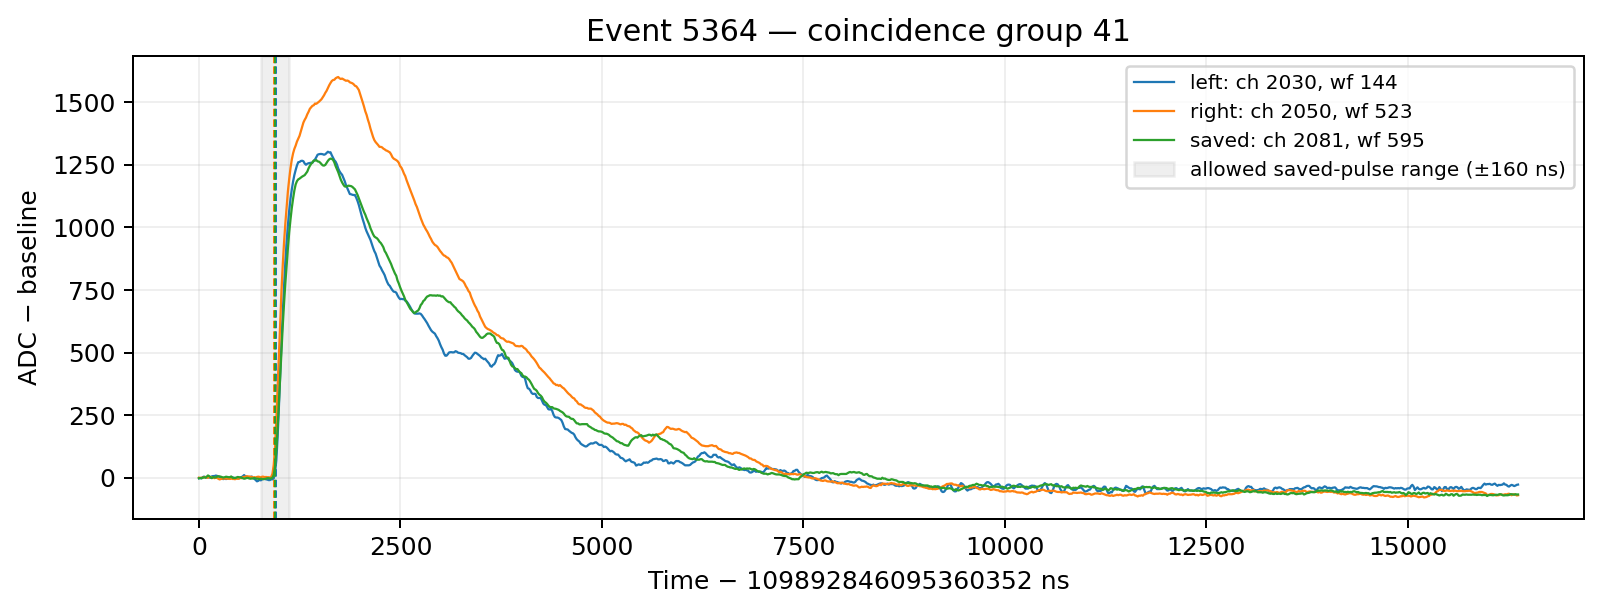


Group 42, CSV row 31714, event 4969
  left : channel=2030, waveform_index=209, timestamp=109892844855047104 ns, pulse_start=59 ticks, pulse_time=109892844855048048 ns
  right: channel=2060, waveform_index=244, timestamp=109892844855047104 ns, pulse_start=63 ticks, pulse_time=109892844855048112 ns
  saved: channel=2081, waveform_index=561, timestamp=109892844855047104 ns, pulse_start=59 ticks, pulse_time=109892844855048048 ns
  dt_ns_coinc: CSV=64, calculated=64
  dt_ns_save:  CSV=0, calculated=0


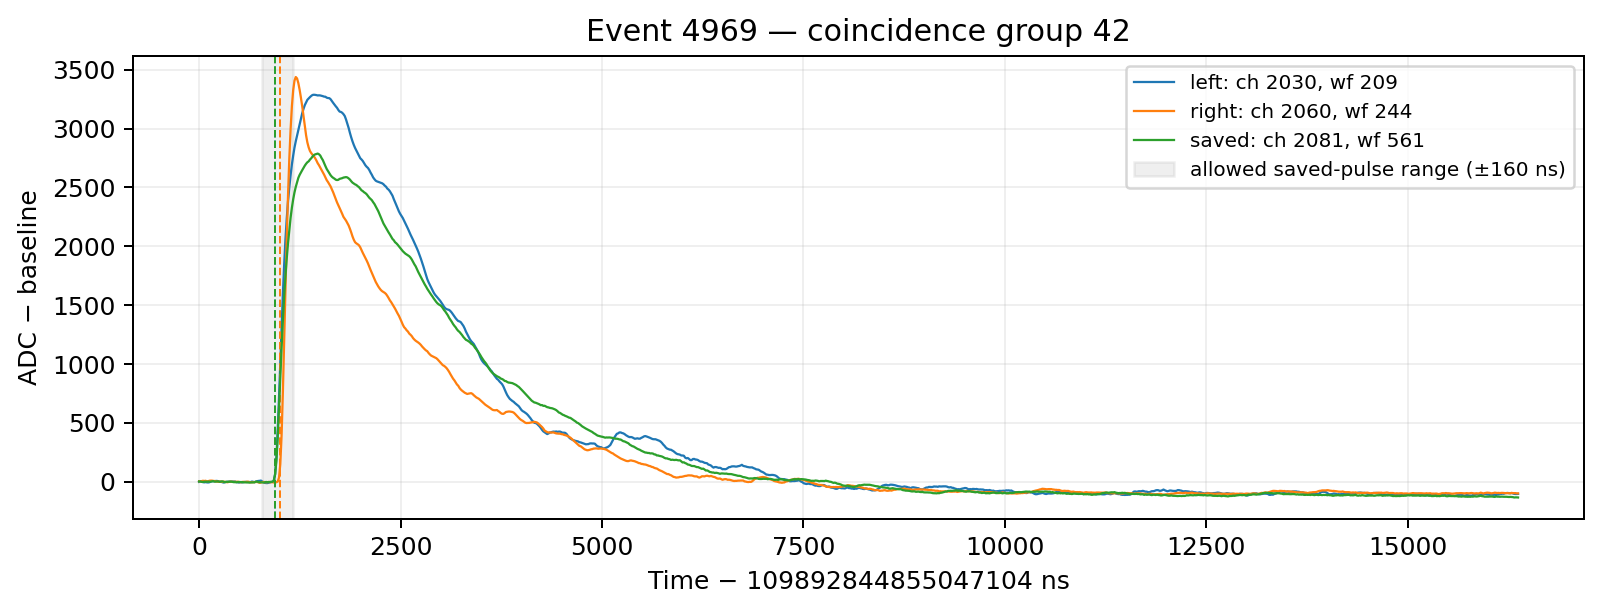


Group 43, CSV row 1409, event 225
  left : channel=2031, waveform_index=161, timestamp=109892829951277360 ns, pulse_start=59 ticks, pulse_time=109892829951278304 ns
  right: channel=2060, waveform_index=204, timestamp=109892829951277360 ns, pulse_start=61 ticks, pulse_time=109892829951278336 ns
  saved: channel=2081, waveform_index=582, timestamp=109892829951277360 ns, pulse_start=58 ticks, pulse_time=109892829951278288 ns
  dt_ns_coinc: CSV=32, calculated=32
  dt_ns_save:  CSV=-16, calculated=-16


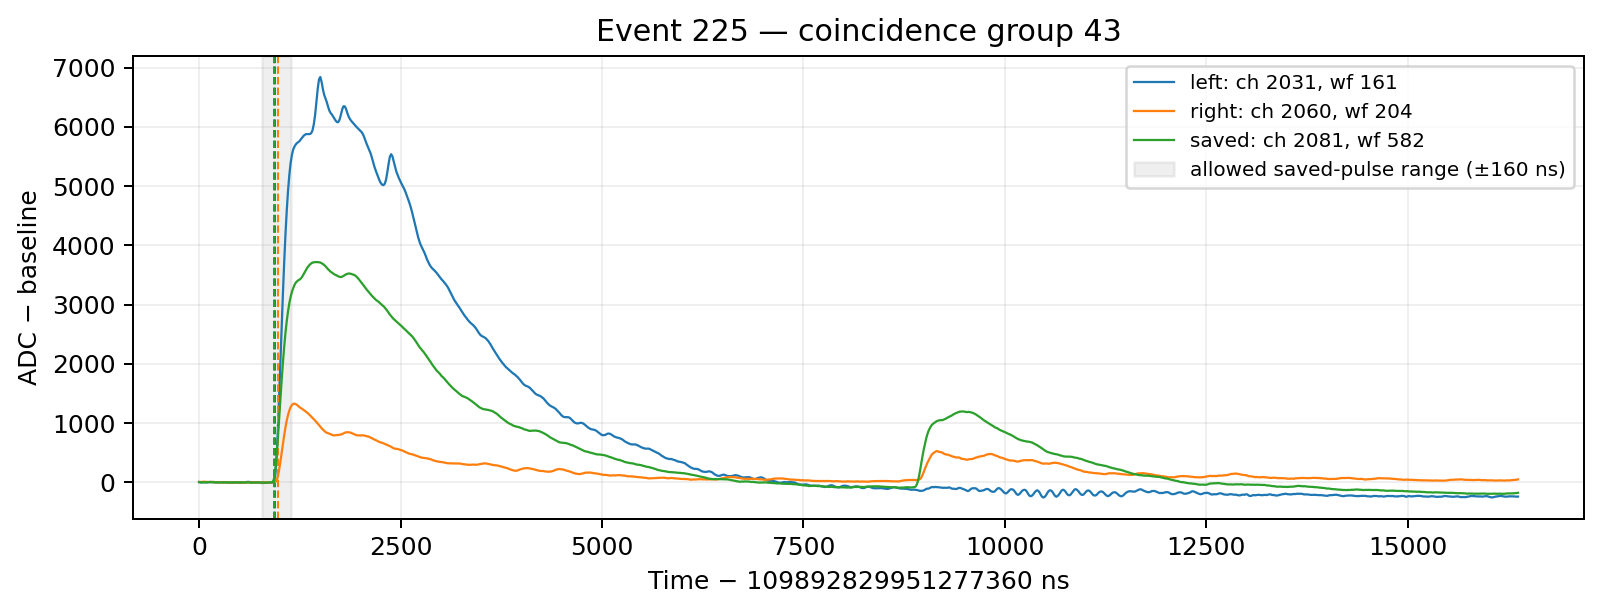


Group 44, CSV row 24601, event 3850
  left : channel=2031, waveform_index=252, timestamp=109892841338954976 ns, pulse_start=60 ticks, pulse_time=109892841338955936 ns
  right: channel=2050, waveform_index=194, timestamp=109892841338954976 ns, pulse_start=59 ticks, pulse_time=109892841338955920 ns
  saved: channel=2081, waveform_index=133, timestamp=109892841338954992 ns, pulse_start=58 ticks, pulse_time=109892841338955920 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=0, calculated=0


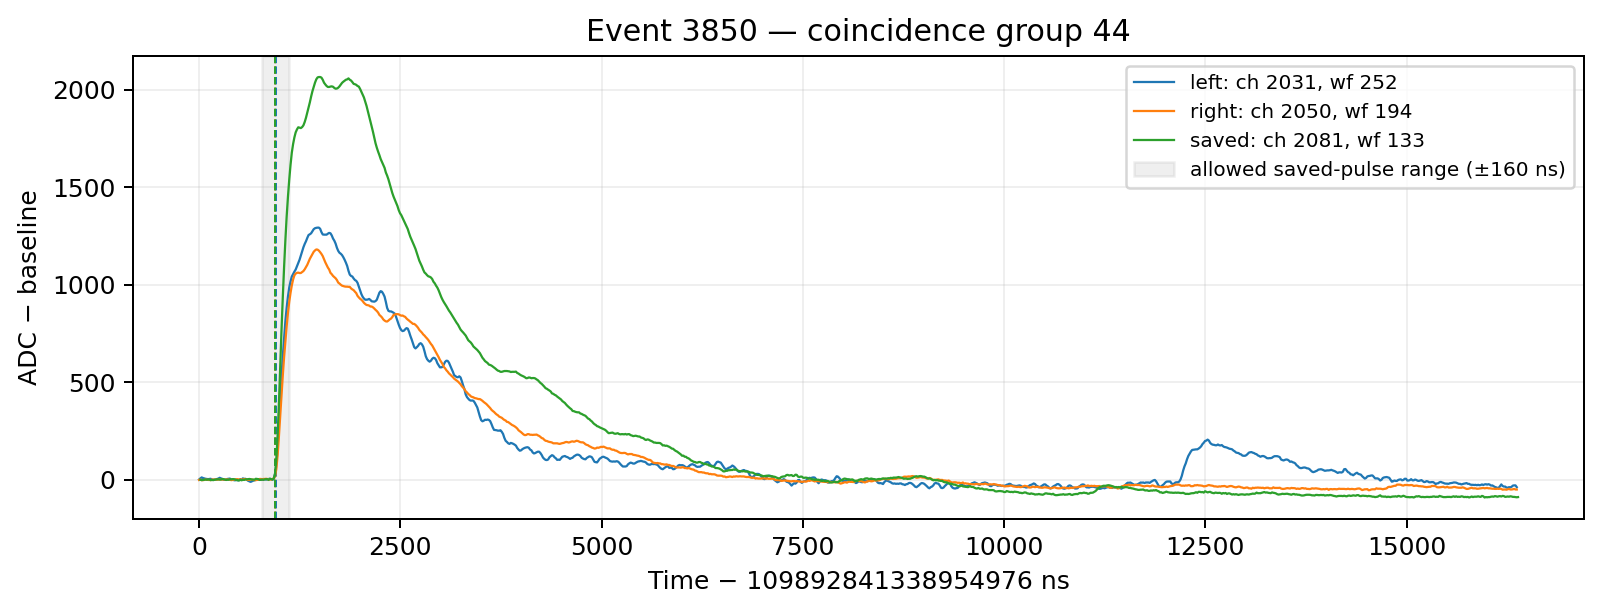


Group 45, CSV row 25738, event 4030
  left : channel=2030, waveform_index=234, timestamp=109892841904842560 ns, pulse_start=60 ticks, pulse_time=109892841904843520 ns
  right: channel=2050, waveform_index=268, timestamp=109892841904842560 ns, pulse_start=59 ticks, pulse_time=109892841904843504 ns
  saved: channel=2080, waveform_index=304, timestamp=109892841904842560 ns, pulse_start=59 ticks, pulse_time=109892841904843504 ns
  dt_ns_coinc: CSV=-16, calculated=-16
  dt_ns_save:  CSV=0, calculated=0


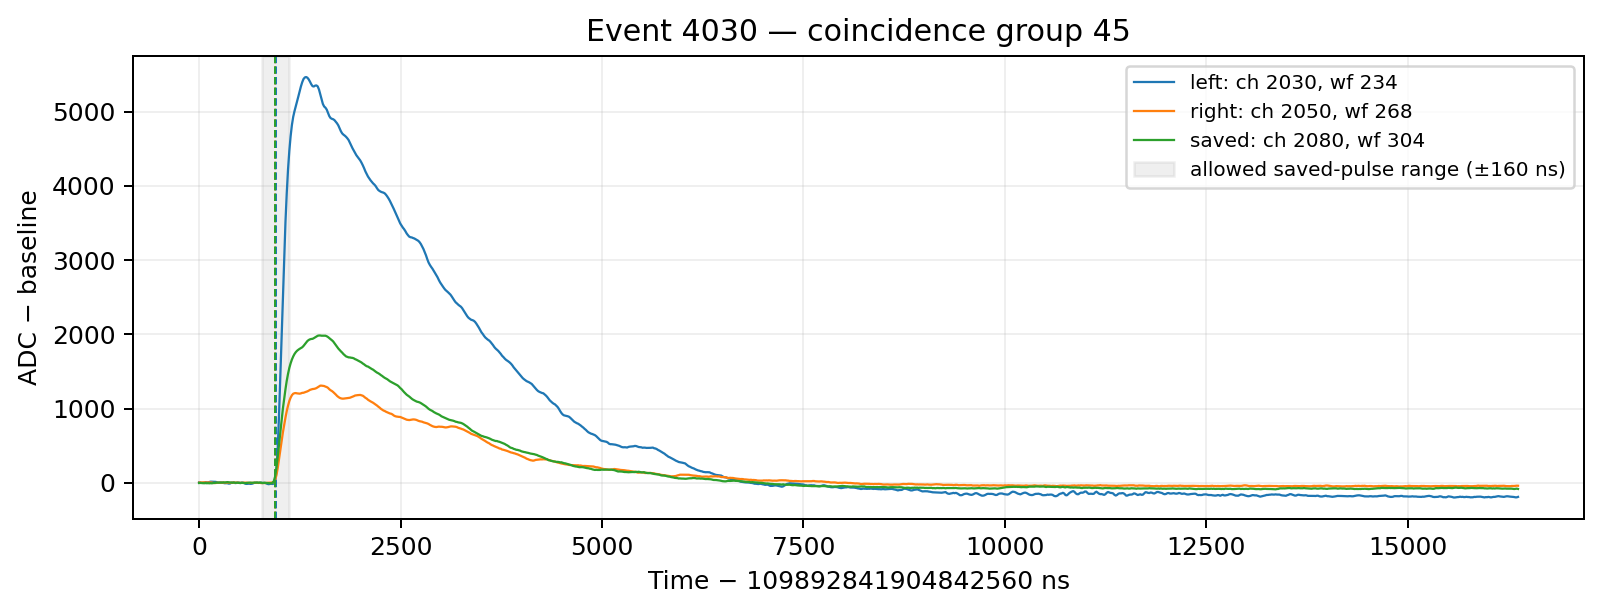


Group 46, CSV row 3956, event 619
  left : channel=2031, waveform_index=159, timestamp=109892831189111232 ns, pulse_start=60 ticks, pulse_time=109892831189112192 ns
  right: channel=2060, waveform_index=212, timestamp=109892831189111232 ns, pulse_start=65 ticks, pulse_time=109892831189112272 ns
  saved: channel=2081, waveform_index=69, timestamp=109892831189111232 ns, pulse_start=57 ticks, pulse_time=109892831189112144 ns
  dt_ns_coinc: CSV=80, calculated=80
  dt_ns_save:  CSV=-48, calculated=-48


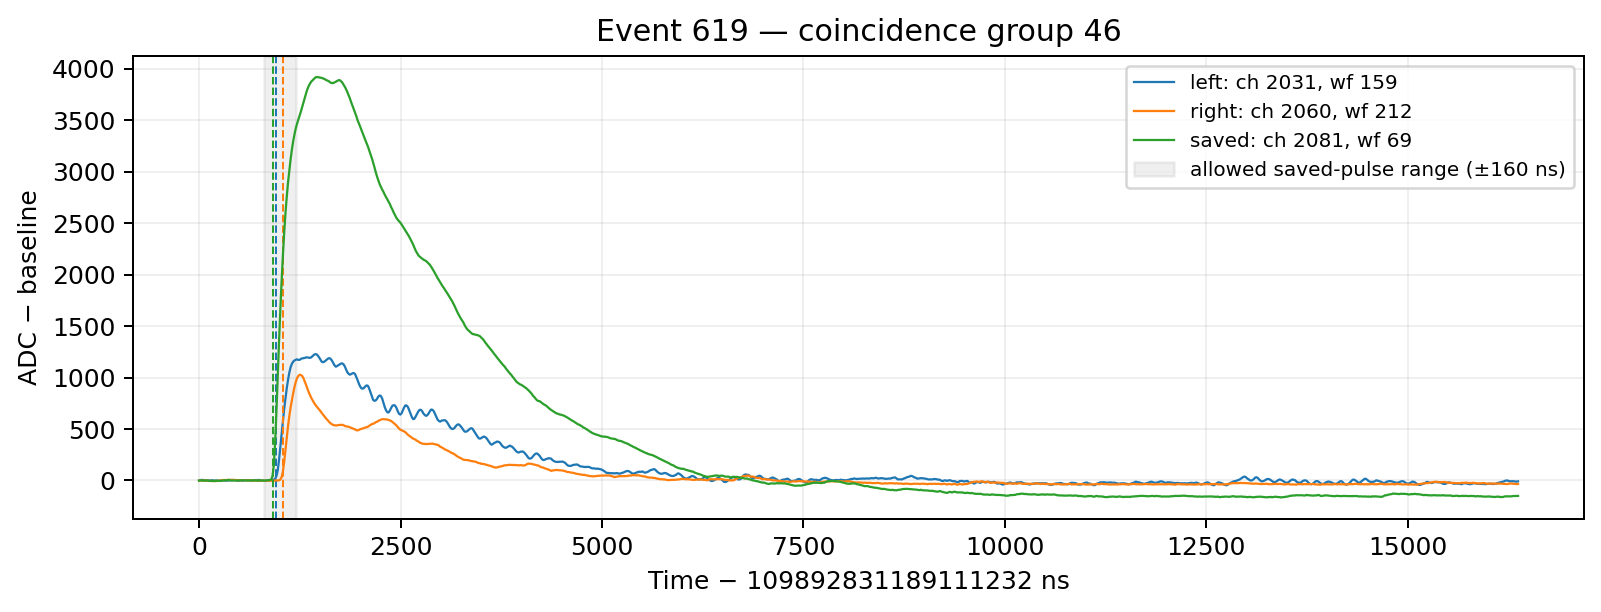


Group 47, CSV row 21927, event 3424
  left : channel=2031, waveform_index=194, timestamp=109892840000965648 ns, pulse_start=59 ticks, pulse_time=109892840000966592 ns
  right: channel=2050, waveform_index=97, timestamp=109892840000965648 ns, pulse_start=60 ticks, pulse_time=109892840000966608 ns
  saved: channel=2081, waveform_index=436, timestamp=109892840000965664 ns, pulse_start=57 ticks, pulse_time=109892840000966576 ns
  dt_ns_coinc: CSV=16, calculated=16
  dt_ns_save:  CSV=-16, calculated=-16


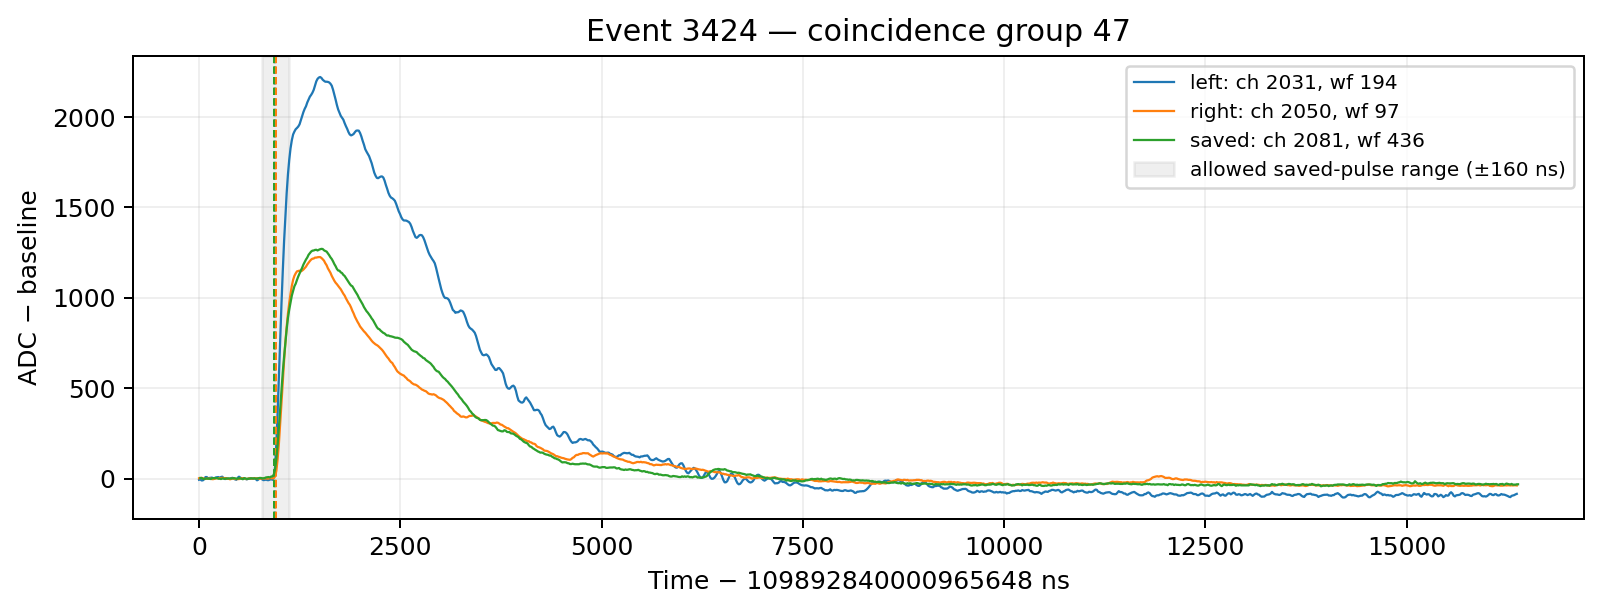


Group 48, CSV row 6082, event 942
  left : channel=2030, waveform_index=174, timestamp=109892832204069584 ns, pulse_start=60 ticks, pulse_time=109892832204070544 ns
  right: channel=2050, waveform_index=213, timestamp=109892832204069584 ns, pulse_start=60 ticks, pulse_time=109892832204070544 ns
  saved: channel=2080, waveform_index=248, timestamp=109892832204069584 ns, pulse_start=59 ticks, pulse_time=109892832204070528 ns
  dt_ns_coinc: CSV=0, calculated=0
  dt_ns_save:  CSV=-16, calculated=-16


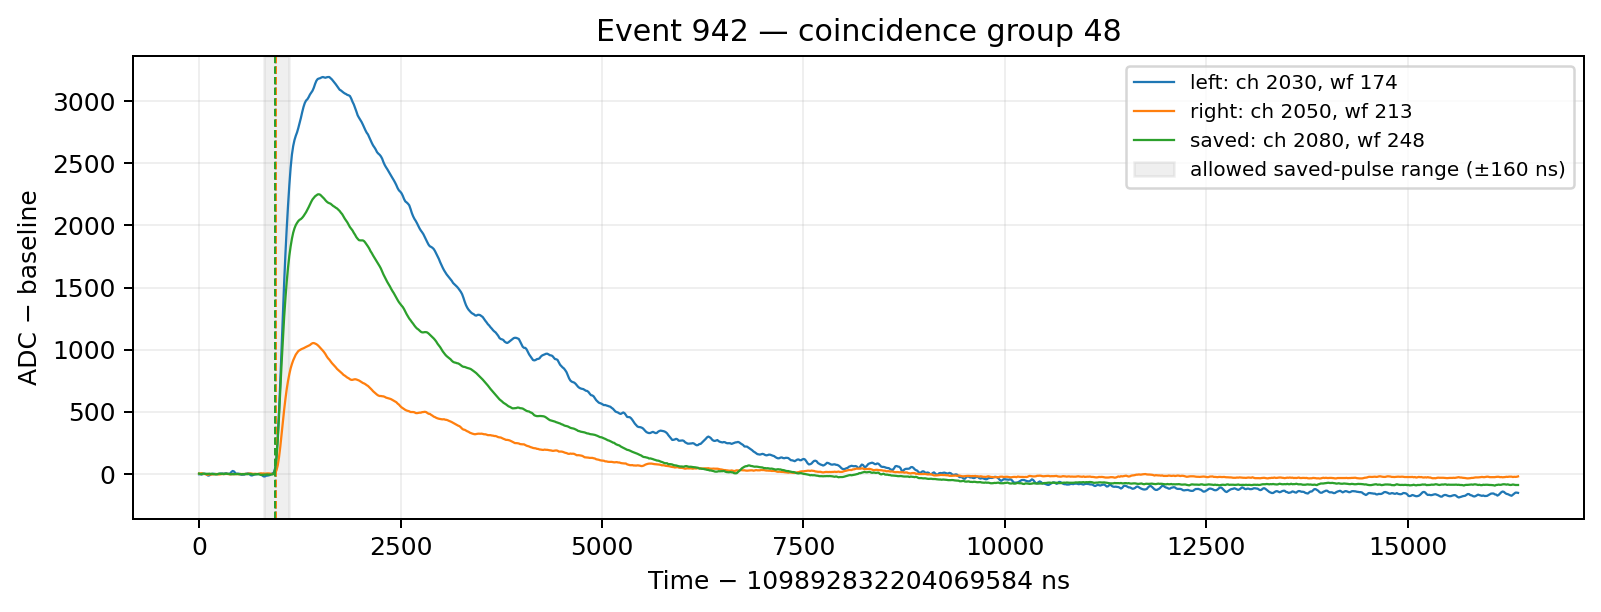


Group 49, CSV row 5164, event 799
  left : channel=2031, waveform_index=175, timestamp=109892831755091696 ns, pulse_start=59 ticks, pulse_time=109892831755092640 ns
  right: channel=2050, waveform_index=354, timestamp=109892831755091696 ns, pulse_start=61 ticks, pulse_time=109892831755092672 ns
  saved: channel=2081, waveform_index=579, timestamp=109892831755091696 ns, pulse_start=58 ticks, pulse_time=109892831755092624 ns
  dt_ns_coinc: CSV=32, calculated=32
  dt_ns_save:  CSV=-16, calculated=-16


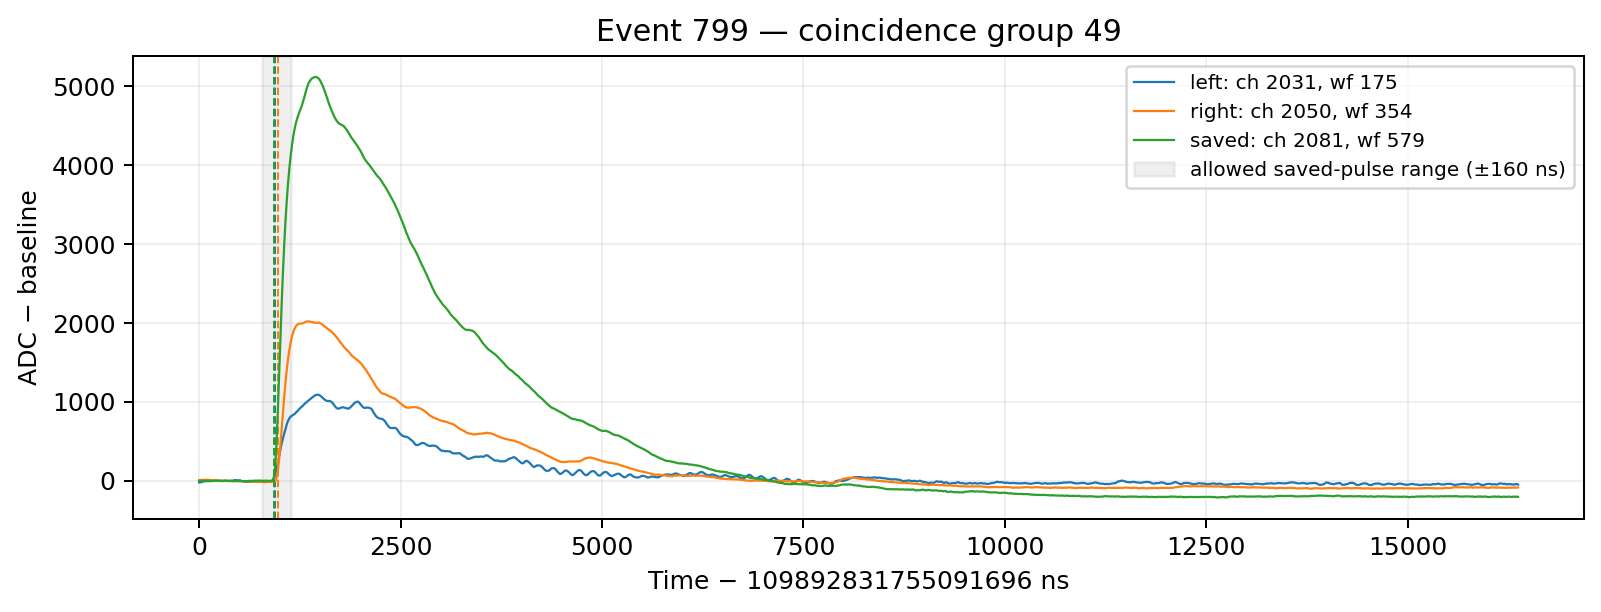


Group 50, CSV row 36708, event 5777
  left : channel=2031, waveform_index=346, timestamp=109892847392854432 ns, pulse_start=60 ticks, pulse_time=109892847392855392 ns
  right: channel=2060, waveform_index=293, timestamp=109892847392854432 ns, pulse_start=64 ticks, pulse_time=109892847392855456 ns
  saved: channel=2080, waveform_index=226, timestamp=109892847392854432 ns, pulse_start=57 ticks, pulse_time=109892847392855344 ns
  dt_ns_coinc: CSV=64, calculated=64
  dt_ns_save:  CSV=-48, calculated=-48


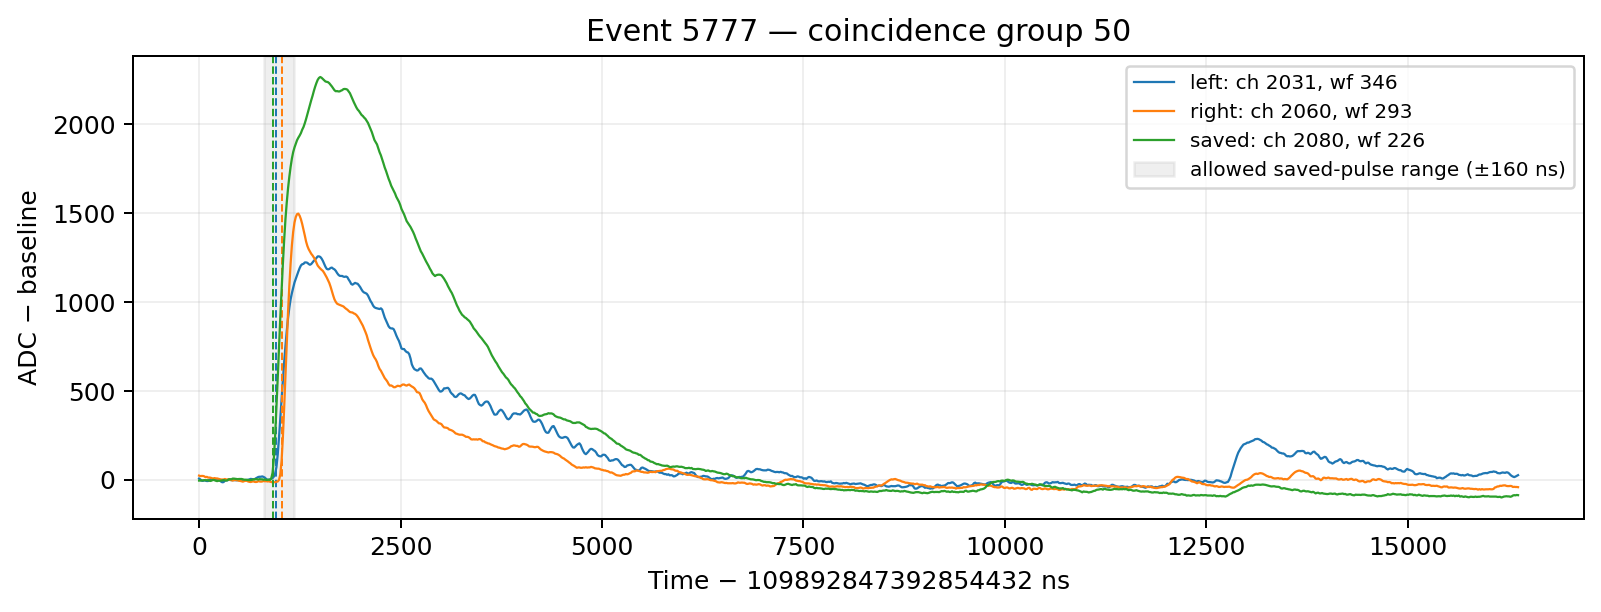

In [6]:

# ------------------------------------------------------------------
# Locate selected ROOT entries and timestamps without loading ADC vectors
# ------------------------------------------------------------------

channel_filter = " || ".join(
    f"channel == {channel}" for channel in selected_channels
)

metadata = (
    ROOT.RDataFrame(chain)
    .Filter(f"({channel_filter})")
    .Define("entry_index", "rdfentry_")
    .AsNumpy(
        ["entry_index", "event", "channel", "waveform_index", "timestamp"]
    )
)

entry_by_key = {}
timestamp_by_key = {}

for entry, event, channel, waveform_index, timestamp in zip(
    metadata["entry_index"],
    metadata["event"],
    metadata["channel"],
    metadata["waveform_index"],
    metadata["timestamp"],
):
    key = (
        int(event),
        int(channel),
        int(waveform_index),
    )

    if key in selected_keys:
        entry_by_key[key] = int(entry)
        timestamp_by_key[key] = int(timestamp)

missing_keys = selected_keys - set(entry_by_key)

if missing_keys:
    examples = sorted(missing_keys)[:10]
    raise RuntimeError(
        f"{len(missing_keys)} selected waveforms were not found. "
        f"Examples: {examples}"
    )

print(f"Located ROOT entries: {len(entry_by_key):,}")

# ------------------------------------------------------------------
# Load the ADC vectors for the sampled saved/left/right waveform groups
# ------------------------------------------------------------------

# Reading unique keys in ROOT-entry order reduces file seeking.
keys_to_load = sorted(selected_keys, key=lambda key: entry_by_key[key])

chain.SetBranchStatus("*", 0)
chain.SetBranchStatus("adc", 1)

analyzer = WaveformAnalyzer(CONFIG_FILE)
waveform_by_key = {}
waveforms_by_channel = defaultdict(list)

for key in keys_to_load:
    entry = entry_by_key[key]

    if chain.GetEntry(entry) <= 0:
        raise RuntimeError(f"Could not read ROOT entry {entry}")

    adc = np.fromiter(
        chain.adc,
        dtype=np.int16,
        count=len(chain.adc),
    )

    event, channel, waveform_index = key
    timestamp = timestamp_by_key[key]
    baseline = analyzer.noise_baseline(adc, channel)
    pulse_start = analyzer.pulse_start(adc, channel)
    record = {
        "event": event,
        "channel": channel,
        "waveform_index": waveform_index,
        "timestamp": timestamp,
        "pulse_start": pulse_start,
        "pulse_time": timestamp + pulse_start * SAMPLE_PERIOD_NS,
        "baseline": baseline,
        "adc": adc,
    }
    waveform_by_key[key] = record
    waveforms_by_channel[channel].append(record)

# Keep each saved waveform associated with the exact pair that selected it.
coincidence_groups = []
for csv_index, row in example_rows.iterrows():
    save_key = (
        int(row["event"]),
        int(row[save_channel_column]),
        int(row["waveform_index_save"]),
    )
    left_key = (
        int(row["event"]),
        int(row["channel_coincident_left"]),
        int(row["waveform_index_coincident_left"]),
    )
    right_key = (
        int(row["event"]),
        int(row["channel_coincident_right"]),
        int(row["waveform_index_coincident_right"]),
    )
    coincidence_groups.append({
        "csv_index": int(csv_index),
        "dt_ns_coinc_csv": int(row["dt_ns_coinc"]),
        "dt_ns_save_csv": int(row["dt_ns_save"]),
        "saved": waveform_by_key[save_key],
        "left": waveform_by_key[left_key],
        "right": waveform_by_key[right_key],
    })

# Print timestamps and plot each triplet on a common absolute-time axis.
window_ns = WINDOW_TICKS * SAMPLE_PERIOD_NS
colors = {"saved": "tab:green", "left": "tab:blue", "right": "tab:orange"}

for group_number, group in enumerate(coincidence_groups, start=1):
    saved = group["saved"]
    left = group["left"]
    right = group["right"]
    pair_min_time = min(left["pulse_time"], right["pulse_time"])
    pair_max_time = max(left["pulse_time"], right["pulse_time"])
    reference_time = min(record["timestamp"] for record in (saved, left, right))

    print(f"\nGroup {group_number}, CSV row {group['csv_index']}, event {saved['event']}")
    for role in ("left", "right", "saved"):
        record = group[role]
        print(
            f"  {role:5s}: channel={record['channel']}, "
            f"waveform_index={record['waveform_index']}, "
            f"timestamp={record['timestamp']} ns, "
            f"pulse_start={record['pulse_start']} ticks, "
            f"pulse_time={record['pulse_time']} ns"
        )

    calculated_dt_coinc = right["pulse_time"] - left["pulse_time"]
    calculated_dt_save = saved["pulse_time"] - pair_min_time
    print(
        f"  dt_ns_coinc: CSV={group['dt_ns_coinc_csv']}, "
        f"calculated={calculated_dt_coinc}"
    )
    print(
        f"  dt_ns_save:  CSV={group['dt_ns_save_csv']}, "
        f"calculated={calculated_dt_save}"
    )

    figure, axis = plt.subplots(dpi=180, figsize=(9, 3.5))
    for role in ("left", "right", "saved"):
        record = group[role]
        time_ns = (
            record["timestamp"] - reference_time
            + np.arange(len(record["adc"])) * SAMPLE_PERIOD_NS
        )
        axis.plot(
            time_ns,
            record["adc"].astype(float) - record["baseline"],
            color=colors[role],
            linewidth=0.9,
            label=(
                f"{role}: ch {record['channel']}, "
                f"wf {record['waveform_index']}"
            ),
        )
        axis.axvline(
            record["pulse_time"] - reference_time,
            color=colors[role],
            linestyle="--",
            linewidth=0.8,
        )

    axis.axvspan(
        pair_min_time - window_ns - reference_time,
        pair_max_time + window_ns - reference_time,
        color="0.5",
        alpha=0.12,
        label=f"allowed saved-pulse range (±{window_ns} ns)",
    )
    axis.set_title(f"Event {saved['event']} — coincidence group {group_number}")
    axis.set_xlabel(f"Time − {reference_time} ns")
    axis.set_ylabel("ADC − baseline")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
    figure.tight_layout()
    plt.show()
